# Grafi — Analiza slovenskega nepremičninskega trga (2015–2025)
**Vir:** GURS — Evidenca trga nepremičnin (ETN) | **Filter:** tržni posli, površina > 5 m², 300 < €/m² < 15.000

## Setup — zaženi enkrat pred vsemi grafi

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.color": "#e0e0e0",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

OBCINE = [
    "LJUBLJANA", "MARIBOR", "CELJE", "KOPER", "KRANJ",
    "DOMŽALE", "NOVO MESTO", "VELENJE", "KAMNIK", "NOVA GORICA"
]

BARVE = {
    "LJUBLJANA":   "#E53935",
    "MARIBOR":     "#1E88E5",
    "CELJE":       "#43A047",
    "KOPER":       "#FB8C00",
    "KRANJ":       "#8E24AA",
    "DOMŽALE":     "#00ACC1",
    "NOVO MESTO":  "#F4511E",
    "VELENJE":     "#6D4C41",
    "KAMNIK":      "#546E7A",
    "NOVA GORICA": "#FFB300",
}

# ── Nalaganje surovih podatkov ───────────────────────────────────────────────
df_raw = pd.read_csv("vsi_bivanski.csv", low_memory=False)

# ── Izpeljani stolpci ────────────────────────────────────────────────────────
def klasificiraj_tip(raba):
    """Klasificira nepremičnino kot Hišo ali Stanovanje na podlagi GURS šifre."""
    r = str(raba).strip()
    if r.startswith("111") or r.startswith("1 -") or r.startswith("1-"):
        return "Hiša"
    elif r.startswith("112") or r.startswith("2 -") or r.startswith("2-") or r.startswith("47") or r.startswith("3 -"):
        return "Stanovanje"
    return "Drugo"

df_raw["TIP"]      = df_raw["DEJANSKA_RABA_DELA_STAVBE"].apply(klasificiraj_tip)
df_raw["LETO"]     = df_raw["LETO_x"]
df_raw["POVRSINA"] = df_raw["POVRSINA_DELA_STAVBE"]
# Opomba: V vsi_bivanski.csv je POGODBENA_CENA_DELA_STAVBE skoraj prazna,
# zato uporabljamo POGODBENA_CENA_ODSKODNINA (skupna pogodbena vrednost).
df_raw["CENA_M2"]  = df_raw["POGODBENA_CENA_ODSKODNINA"] / df_raw["POVRSINA"]

# ── Filter tržnih poslov ─────────────────────────────────────────────────────
# GURS šifrant TRZNOST_POSLA se je v opazovanem obdobju večkrat spremenil:
#   2015–2019: pretežno koda 1
#   2020–2022: pretežno koda 2 (sprememba šifranta)
#   2023–2024: kombinacija kod 1 in 2
#   2025:      pretežno koda 5 (nova oznaka)
# Za konsistentno definicijo tržnega posla skozi celotno obdobje vključujemo
# vse tri oznake.
TRZNI_KODI = [1, 2, 5]

df_filt = df_raw[
    df_raw["OBCINA"].isin(OBCINE) &
    df_raw["TRZNOST_POSLA"].isin(TRZNI_KODI) &
    (df_raw["POVRSINA"] > 5) &
    (df_raw["POGODBENA_CENA_ODSKODNINA"] > 0) &
    (df_raw["CENA_M2"] > 300) &
    (df_raw["CENA_M2"] < 15_000) &
    df_raw["TIP"].isin(["Hiša", "Stanovanje"]) &
    df_raw["LETO"].between(2015, 2025)
].copy().reset_index(drop=True)

# ── IQR filter po OBCINA + TIP + LETO (odstrani 5 % najnižjih in 5 % najvišjih) ──
# Odstrani ekstremne vrednosti znotraj posamezne občine, tipa in leta,
# da zmanjšamo vpliv napak vnosa in posebnih primerov.
mask_iqr = df_filt.groupby(["OBCINA", "TIP", "LETO"])["CENA_M2"].transform(
    lambda g: (g >= g.quantile(0.05)) & (g <= g.quantile(0.95))
)
df = df_filt[mask_iqr].copy().reset_index(drop=True)

print(f"Pred IQR: {len(df_filt):,}  |  Po IQR (5-95 %): {len(df):,}")
print(f"  Hiše: {(df['TIP']=='Hiša').sum():,}  |  Stanovanja: {(df['TIP']=='Stanovanje').sum():,}")
print(f"Po letih:")
for leto in range(2015, 2026):
    n = (df['LETO'] == leto).sum()
    print(f"  {leto}: {n:,}")


Pred IQR: 60,771  |  Po IQR (5-95 %): 54,518
  Hiše: 8,582  |  Stanovanja: 45,936
Po letih:
  2015: 4,074
  2016: 5,278
  2017: 5,754
  2018: 4,912
  2019: 5,578
  2020: 4,907
  2021: 5,303
  2022: 4,920
  2023: 4,239
  2024: 4,177
  2025: 5,376


---
## Graf 1 — Gibanje mediane cen/m² po občinah (2015–2025)

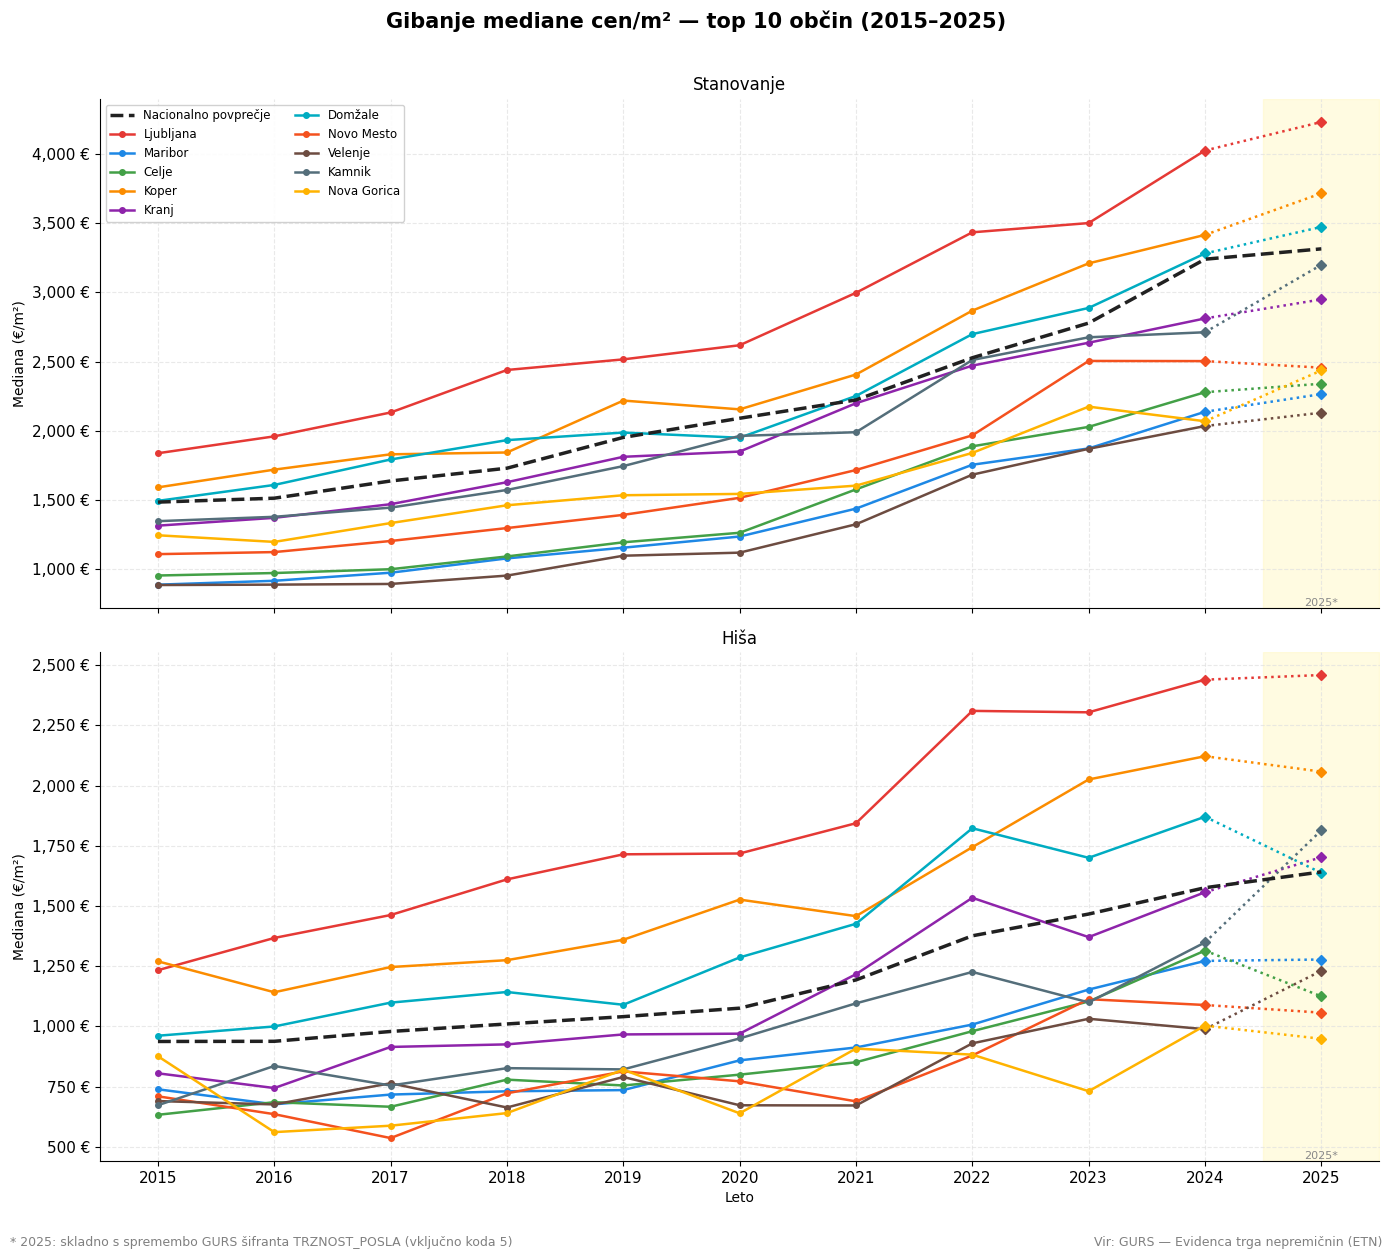

✓ Shranjeno: graf1_cene_trend.png


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
fig.suptitle("Gibanje mediane cen/m² — top 10 občin (2015–2025)", fontsize=15, fontweight="bold", y=1.01)

LETA = list(range(2015, 2026))

for ax, tip in zip(axes, ["Stanovanje", "Hiša"]):
    pod = df[df["TIP"] == tip]

    # Nacionalno povprečje
    nat = pod.groupby("LETO")["CENA_M2"].median()
    ax.plot(nat.index, nat.values, color="#212121", linewidth=2.5,
            linestyle="--", zorder=5, label="Nacionalno povprečje")

    for obcina in OBCINE:
        serie = pod[pod["OBCINA"] == obcina].groupby("LETO")["CENA_M2"].median()
        if serie.empty:
            continue

        # 2015–2024: polna črta
        s24 = serie[serie.index <= 2024]
        ax.plot(s24.index, s24.values, color=BARVE[obcina], linewidth=1.8,
                marker="o", markersize=4, label=obcina.title())

        # 2024–2025: črtkana črta (delni podatki)
        s25 = serie[serie.index >= 2024]
        if len(s25) >= 2:
            ax.plot(s25.index, s25.values, color=BARVE[obcina], linewidth=1.8,
                    linestyle=":", marker="D", markersize=5)

    ax.set_title(tip, fontsize=12, pad=6)
    ax.set_ylabel("Mediana (€/m²)", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f} €"))
    ax.set_xticks(LETA)
    ax.set_xlim(2014.5, 2025.5)

    # Legenda samo na prvem subplotu, izven grafa
    if tip == "Stanovanje":
        ax.legend(loc="upper left", fontsize=8.5, ncol=2,
                  framealpha=0.9, edgecolor="#cccccc")

    # Oznaka za 2025
    ax.axvspan(2024.5, 2025.5, color="#FFF9C4", alpha=0.5, zorder=0)
    ax.text(2025, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 400,
            "2025*", ha="center", va="bottom", fontsize=8, color="#888")

axes[1].set_xlabel("Leto", fontsize=10)

fig.text(0.01, -0.02, "* 2025: skladno s spremembo GURS šifranta TRZNOST_POSLA (vključno koda 5)",
         fontsize=9, color="gray")
fig.text(0.99, -0.02, "Vir: GURS — Evidenca trga nepremičnin (ETN)",
         fontsize=9, color="gray", ha="right")

plt.tight_layout()
plt.savefig("graf1_cene_trend.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Shranjeno: graf1_cene_trend.png")

---
## Graf 2 — Intenziteta trga: tržni posli na 1.000 prebivalcev (2015–2025)
Vir populacije: SURS — Število prebivalcev po občinah, 1. januar vsako leto.  
URL: https://pxweb.stat.si/ (tabela 05C4002S)

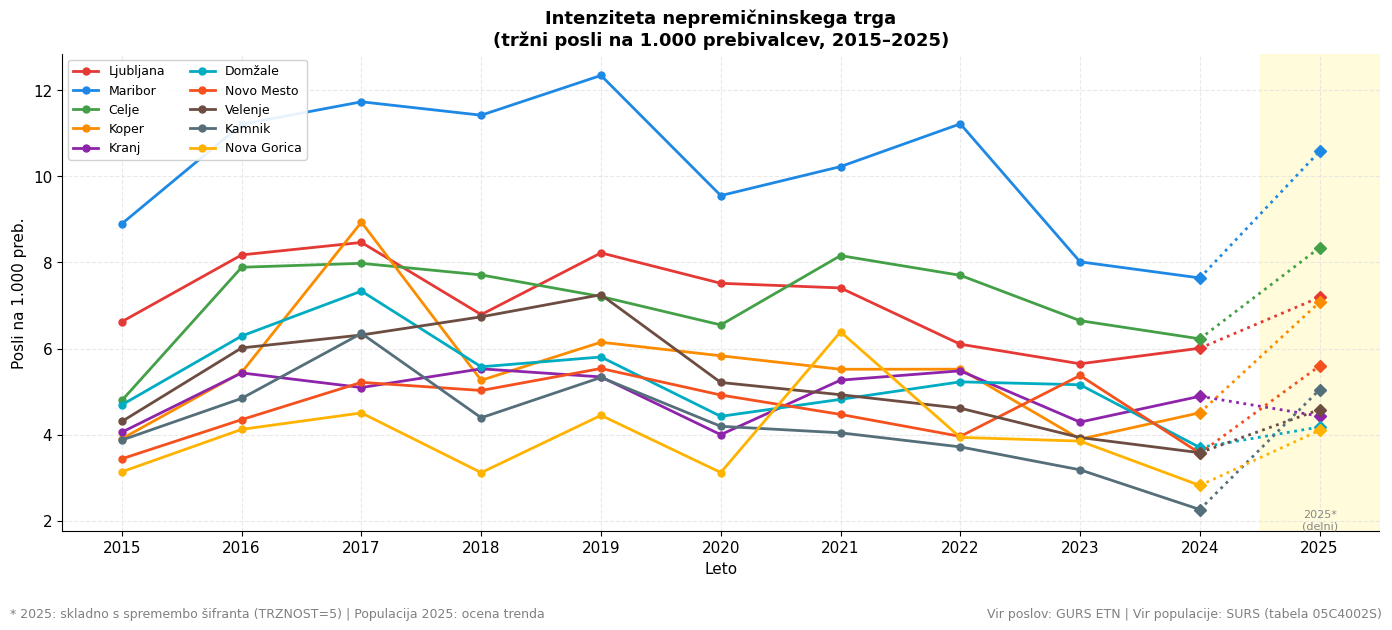

✓ Shranjeno: graf2_intenziteta_trga.png


In [15]:
# Populacija po občinah in letih — vir: SURS, tabela 05C4002S
# https://pxweb.stat.si/pxweb/sl/stat/stat__05__prebivalstvo__10__stevilo_preb__05__05C40__/05C4002S.px/
POPULACIJA = {
    "LJUBLJANA":   {2015:288307, 2016:290021, 2017:292988, 2018:295504, 2019:297974,
                   2020:294054, 2021:309401, 2022:313123, 2023:316537, 2024:319283, 2025:321000},
    "MARIBOR":     {2015:95171,  2016:95021,  2017:94869,  2018:94743,  2019:94538,
                   2020:112844, 2021:112549, 2022:111950, 2023:111303, 2024:110600, 2025:110000},
    "CELJE":       {2015:49006,  2016:49060,  2017:49126,  2018:49160,  2019:49249,
                   2020:50394,  2021:50501,  2022:50516,  2023:50547,  2024:50600,  2025:50700},
    "KOPER":       {2015:52490,  2016:52866,  2017:53383,  2018:53780,  2019:54175,
                   2020:52990,  2021:53459,  2022:53980,  2023:54431,  2024:54800,  2025:55100},
    "KRANJ":       {2015:55954,  2016:56313,  2017:56733,  2018:57159,  2019:57484,
                   2020:57516,  2021:58117,  2022:58556,  2023:58960,  2024:59300,  2025:59600},
    "DOMŽALE":     {2015:35378,  2016:35765,  2017:36133,  2018:36410,  2019:36701,
                   2020:36837,  2021:37142,  2022:37504,  2023:37803,  2024:38100,  2025:38300},
    "NOVO MESTO":  {2015:36348,  2016:36567,  2017:36820,  2018:37010,  2019:37208,
                   2020:37196,  2021:37591,  2022:37891,  2023:38150,  2024:38400,  2025:38600},
    "VELENJE":     {2015:33437,  2016:33253,  2017:33097,  2018:32953,  2019:32828,
                   2020:33002,  2021:32880,  2022:32731,  2023:32550,  2024:32400,  2025:32300},
    "KAMNIK":      {2015:29685,  2016:29943,  2017:30230,  2018:30513,  2019:30779,
                   2020:31002,  2021:31421,  2022:31763,  2023:32053,  2024:32300,  2025:32500},
    "NOVA GORICA": {2015:31884,  2016:32021,  2017:32192,  2018:32400,  2019:32598,
                   2020:32697,  2021:33031,  2022:33291,  2023:33510,  2024:33700,  2025:33900},
}

# Posli po občini in letu
posli = df.groupby(["OBCINA", "LETO"]).size().reset_index(name="N")

# Normalizacija na 1000 prebivalcev
rows = []
for _, row in posli.iterrows():
    pop = POPULACIJA.get(row["OBCINA"], {}).get(int(row["LETO"]))
    if pop:
        rows.append({"OBCINA": row["OBCINA"], "LETO": int(row["LETO"]),
                     "INTENZITETA": row["N"] / pop * 1000})
intenz = pd.DataFrame(rows)

# ── Graf ─────────────────────────────────────────────────────────────────────
LETA = list(range(2015, 2026))

fig, ax = plt.subplots(figsize=(14, 6))

for obcina in OBCINE:
    pod = intenz[intenz["OBCINA"] == obcina].sort_values("LETO")
    if pod.empty:
        continue

    s24 = pod[pod["LETO"] <= 2024]
    ax.plot(s24["LETO"], s24["INTENZITETA"], color=BARVE[obcina],
            linewidth=2, marker="o", markersize=5, label=obcina.title())

    s25 = pod[pod["LETO"] >= 2024]
    if len(s25) >= 2:
        ax.plot(s25["LETO"], s25["INTENZITETA"], color=BARVE[obcina],
                linewidth=2, linestyle=":", marker="D", markersize=6)

# 2025 sivo ozadje + oznaka
ax.axvspan(2024.5, 2025.5, color="#FFF9C4", alpha=0.6, zorder=0)
ax.text(2025, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0,
        "2025*\n(delni)", ha="center", va="bottom", fontsize=8, color="#888")

ax.set_title("Intenziteta nepremičninskega trga\n(tržni posli na 1.000 prebivalcev, 2015–2025)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Leto")
ax.set_ylabel("Posli na 1.000 preb.")
ax.set_xticks(LETA)
ax.set_xlim(2014.5, 2025.5)
ax.legend(fontsize=9, ncol=2, loc="upper left", framealpha=0.9, edgecolor="#ccc")

fig.text(0.01, -0.04, "* 2025: skladno s spremembo šifranta (TRZNOST=5) | Populacija 2025: ocena trenda",
         fontsize=9, color="gray")
fig.text(0.99, -0.04, "Vir poslov: GURS ETN | Vir populacije: SURS (tabela 05C4002S)",
         fontsize=9, color="gray", ha="right")

plt.tight_layout()
plt.savefig("graf2_intenziteta_trga.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Shranjeno: graf2_intenziteta_trga.png")

---
## Graf 3 — Heatmap letnih sprememb mediane cen/m² (YoY %)

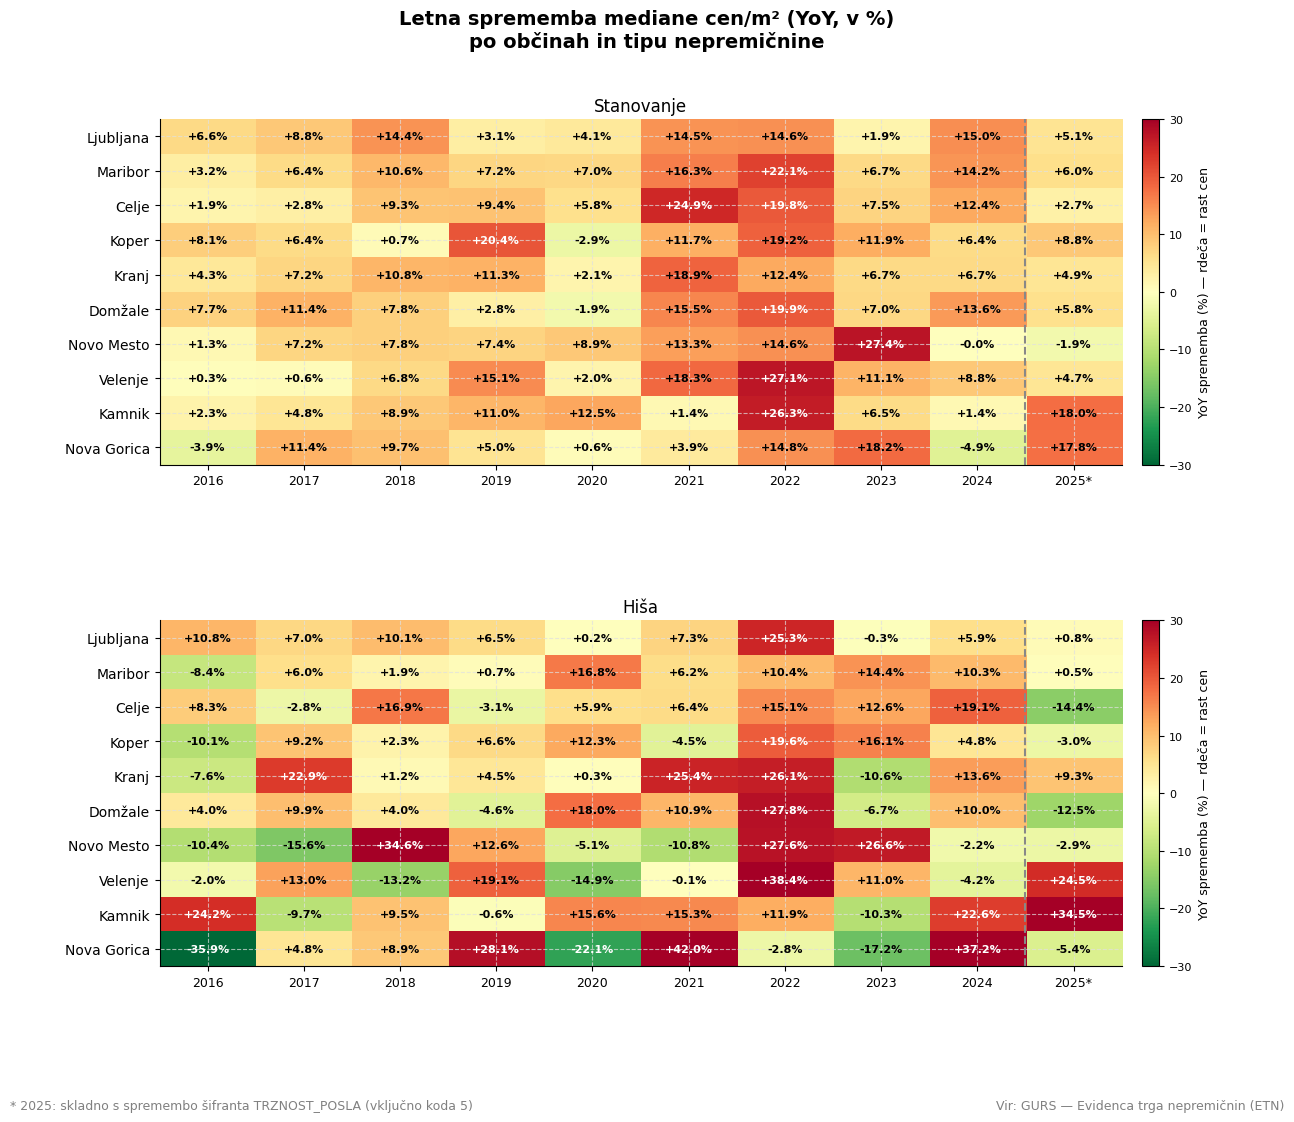

✓ Shranjeno: graf3_heatmap_yoy.png


In [16]:
import matplotlib.colors as mcolors

# Mediana cen/m² po občini in letu (vse nepremičnine skupaj)
pivot = (
    df.groupby(["OBCINA", "LETO"])["CENA_M2"]
    .median()
    .unstack("LETO")
    .reindex(OBCINE)
)

# YoY sprememba v %
yoy = pivot.pct_change(axis=1) * 100
yoy = yoy.loc[:, 2016:]

# ── Barvna lestvica: zelena → bela → rdeča (rast = rdeča, z vidika kupca) ───
vmax = min(max(abs(yoy.values[~np.isnan(yoy.values)])) * 0.9, 30)
cmap = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, axes = plt.subplots(2, 1, figsize=(13, 11), gridspec_kw={"hspace": 0.45})
fig.suptitle("Letna sprememba mediane cen/m² (YoY, v %)\npo občinah in tipu nepremičnine",
             fontsize=14, fontweight="bold")

for ax, tip in zip(axes, ["Stanovanje", "Hiša"]):
    pod = df[df["TIP"] == tip]
    pivot_tip = (
        pod.groupby(["OBCINA", "LETO"])["CENA_M2"]
        .median()
        .unstack("LETO")
        .reindex(OBCINE)
    )
    yoy_tip = pivot_tip.pct_change(axis=1) * 100
    yoy_tip = yoy_tip.loc[:, 2016:]

    # RdYlGn_r = obrnjena paleta → rdeča na vrhu (rast), zelena spodaj (padec)
    im = ax.imshow(yoy_tip.values, aspect="auto",
                   cmap="RdYlGn_r", norm=cmap, interpolation="nearest")

    for i in range(yoy_tip.shape[0]):
        for j in range(yoy_tip.shape[1]):
            val = yoy_tip.values[i, j]
            if np.isnan(val):
                continue
            textcolor = "white" if abs(val) > vmax * 0.65 else "black"
            ax.text(j, i, f"{val:+.1f}%", ha="center", va="center",
                    fontsize=8, color=textcolor, fontweight="bold")

    ax.axvline(x=yoy_tip.shape[1] - 1.5, color="#888", linewidth=1.5, linestyle="--")
    ax.set_xticks(range(yoy_tip.shape[1]))
    ax.set_xticklabels(
        [str(l) if l < 2025 else "2025*" for l in yoy_tip.columns],
        fontsize=9
    )
    ax.set_yticks(range(len(OBCINE)))
    ax.set_yticklabels([o.title() for o in OBCINE], fontsize=10)
    ax.set_title(tip, fontsize=12, pad=6)

    cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.025, pad=0.02)
    cbar.set_label("YoY sprememba (%) — rdeča = rast cen", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

fig.text(0.01, -0.02, "* 2025: skladno s spremembo šifranta TRZNOST_POSLA (vključno koda 5)",
         fontsize=9, color="gray")
fig.text(0.99, -0.02, "Vir: GURS — Evidenca trga nepremičnin (ETN)",
         fontsize=9, color="gray", ha="right")

plt.savefig("graf3_heatmap_yoy.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Shranjeno: graf3_heatmap_yoy.png")

---
## Graf 4 — Dostopnost stanovanj: leta varčevanja za 60 m² stanovanja (2015–2025)

Trije scenariji:
- **S1 – 100 % neto plače:** referenčna zgornja meja, koliko let bi trajalo ob varčevanju celotne plače
- **S2 – 30 % neto plače:** realni delež dohodka za varčevanje (Eurostat: povprečni Slovenec nameni ~17–20 % za bivanje, varčevanje ob tem ~25–30 %)
- **S3 – hipotekarni obrok:** mesečni obrok pri 20-letnem kreditu, 20 % lastnem vložku, ECB obrestna mera tekočega leta

Vir plač: SURS — Povprečna mesečna neto plača, Slovenija skupaj (SI: tabela 0772010S)  
Vir ECB: ECB — Main refinancing operations rate (letno povprečje)

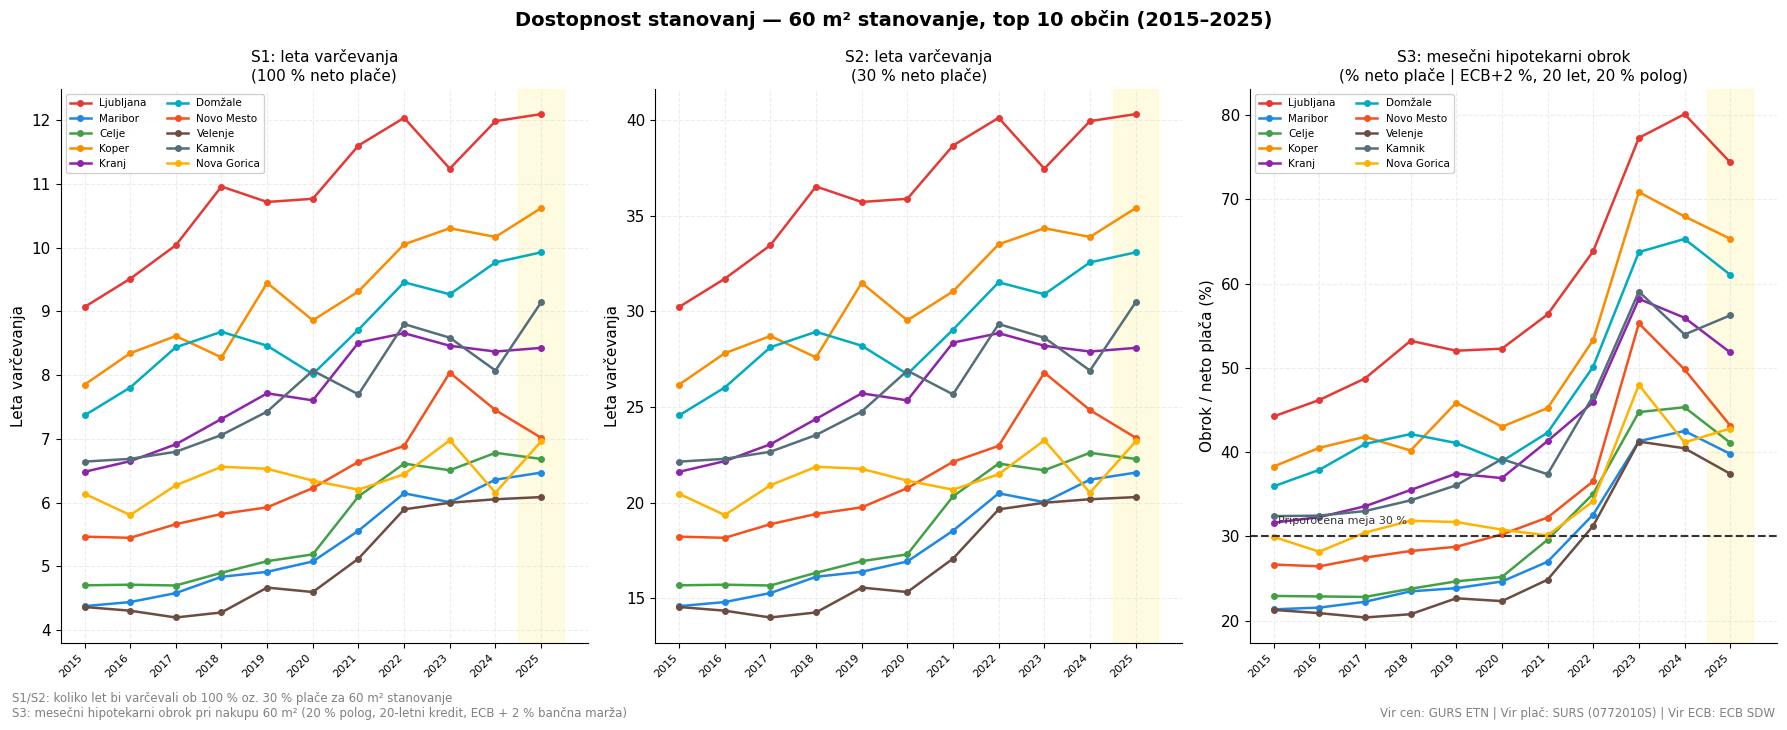

✓ Shranjeno: graf4_dostopnost.png


In [17]:
PLACE = {
    2015: 1013, 2016: 1030, 2017: 1062, 2018: 1113, 2019: 1174,
    2020: 1216, 2021: 1292, 2022: 1427, 2023: 1558, 2024: 1680, 2025: 1750,
}
ECB_RATE = {
    2015: 0.05, 2016: 0.00, 2017: 0.00, 2018: 0.00, 2019: 0.00,
    2020: 0.00, 2021: 0.00, 2022: 0.96, 2023: 4.00, 2024: 3.65, 2025: 2.65,
}

POVRSINA_M2  = 60
POLOG_DELEZ  = 0.20
LETA_KREDITA = 20

df_stan = df[df["TIP"] == "Stanovanje"].copy()
cena_m2_leto = (
    df_stan.groupby(["OBCINA", "LETO"])["CENA_M2"]
    .median()
    .reset_index()
)
cena_m2_leto["CENA_60"] = cena_m2_leto["CENA_M2"] * POVRSINA_M2

def mesecni_obrok(posojilo, letna_obr, leta):
    r = letna_obr / 100 / 12
    n = leta * 12
    if r == 0:
        return posojilo / n
    return posojilo * r * (1 + r)**n / ((1 + r)**n - 1)

rezultati = []
for _, row in cena_m2_leto.iterrows():
    leto  = int(row["LETO"])
    cena  = row["CENA_60"]
    placa = PLACE.get(leto, np.nan)
    ecb   = ECB_RATE.get(leto, np.nan)
    if np.isnan(placa) or np.isnan(ecb):
        continue
    hipot_obr = ecb + 2.0
    posojilo  = cena * (1 - POLOG_DELEZ)
    obrok     = mesecni_obrok(posojilo, hipot_obr, LETA_KREDITA)
    rezultati.append({
        "OBCINA": row["OBCINA"], "LETO": leto,
        "S1_LETA":      cena / (placa * 12),
        "S2_LETA":      cena / (placa * 12 * 0.30),
        "S3_OBROK_PCT": obrok / placa * 100,
    })

rez = pd.DataFrame(rezultati)
LETA_OSA = list(range(2015, 2026))

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Dostopnost stanovanj — 60 m² stanovanje, top 10 občin (2015–2025)",
             fontsize=14, fontweight="bold")

# ── S1: Leta varčevanja pri 100 % plače ──────────────────────────────────────
ax = axes[0]
for obcina in OBCINE:
    pod = rez[rez["OBCINA"] == obcina].sort_values("LETO")
    ax.plot(pod["LETO"], pod["S1_LETA"], color=BARVE[obcina],
            linewidth=1.8, marker="o", markersize=4, label=obcina.title())
ax.set_title("S1: leta varčevanja\n(100 % neto plače)", fontsize=11)
ax.set_ylabel("Leta varčevanja")
ax.set_xticks(LETA_OSA); ax.set_xticklabels(LETA_OSA, rotation=45, ha="right", fontsize=8)
ax.axvspan(2024.5, 2025.5, color="#FFF9C4", alpha=0.5, zorder=0)
ax.legend(fontsize=7.5, ncol=2, loc="upper left", framealpha=0.9, edgecolor="#ccc")

# ── S2: Leta varčevanja pri 30 % plače ───────────────────────────────────────
ax = axes[1]
for obcina in OBCINE:
    pod = rez[rez["OBCINA"] == obcina].sort_values("LETO")
    ax.plot(pod["LETO"], pod["S2_LETA"], color=BARVE[obcina],
            linewidth=1.8, marker="o", markersize=4, label=obcina.title())
ax.set_title("S2: leta varčevanja\n(30 % neto plače)", fontsize=11)
ax.set_ylabel("Leta varčevanja")
ax.set_xticks(LETA_OSA); ax.set_xticklabels(LETA_OSA, rotation=45, ha="right", fontsize=8)
ax.axvspan(2024.5, 2025.5, color="#FFF9C4", alpha=0.5, zorder=0)

# ── S3: Mesečni hipotekarni obrok kot % neto plače ───────────────────────────
ax = axes[2]
for obcina in OBCINE:
    pod = rez[rez["OBCINA"] == obcina].sort_values("LETO")
    ax.plot(pod["LETO"], pod["S3_OBROK_PCT"], color=BARVE[obcina],
            linewidth=1.8, marker="o", markersize=4, label=obcina.title())
ax.axhline(y=30, color="#333", linewidth=1.5, linestyle="--")
ax.text(2015.1, 31.5, "Priporočena meja 30 %", fontsize=8, color="#333")
ax.set_title("S3: mesečni hipotekarni obrok\n(% neto plače | ECB+2 %, 20 let, 20 % polog)", fontsize=11)
ax.set_ylabel("Obrok / neto plača (%)")
ax.set_xticks(LETA_OSA); ax.set_xticklabels(LETA_OSA, rotation=45, ha="right", fontsize=8)
ax.axvspan(2024.5, 2025.5, color="#FFF9C4", alpha=0.5, zorder=0)
ax.legend(fontsize=7.5, ncol=2, loc="upper left", framealpha=0.9, edgecolor="#ccc")

for axis in axes:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.grid(True, color="#e0e0e0", linestyle="--", alpha=0.6)

fig.text(0.01, -0.03,
         "S1/S2: koliko let bi varčevali ob 100 % oz. 30 % plače za 60 m² stanovanje\n"
         "S3: mesečni hipotekarni obrok pri nakupu 60 m² (20 % polog, 20-letni kredit, ECB + 2 % bančna marža)",
         fontsize=8.5, color="gray")
fig.text(0.99, -0.03,
         "Vir cen: GURS ETN | Vir plač: SURS (0772010S) | Vir ECB: ECB SDW",
         fontsize=8.5, color="gray", ha="right")

plt.tight_layout()
plt.savefig("graf4_dostopnost.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Shranjeno: graf4_dostopnost.png")

---
## Graf 5 — Napoved mediane cen/m² 2026–2030 (Prophet, 3 scenariji)

Model: Facebook Prophet z dodatnimi regresijskimi spremenljivkami (ECB obrestna mera, inflacija, povprečna plača).  
Učni podatki: nacionalna mediana €/m² (stanovanja), 2015–2024 — **10 letnih opazovanj**.

> ⚠️ **Omejitve modela:** Prophet je zasnovan za dnevne/tedenske serije. Z 10 letnimi točkami in 3 regresijji je model **visoko podvržen prenaučenosti**. Napovedi so ilustrativne in ne nadomeščajo ekonometrične analize. Intervali zaupanja so široki — namerno, ker odražajo negotovost.  
> Scenariji so konstruirani na podlagi predpostavk, ne verjetnostnih modelov.

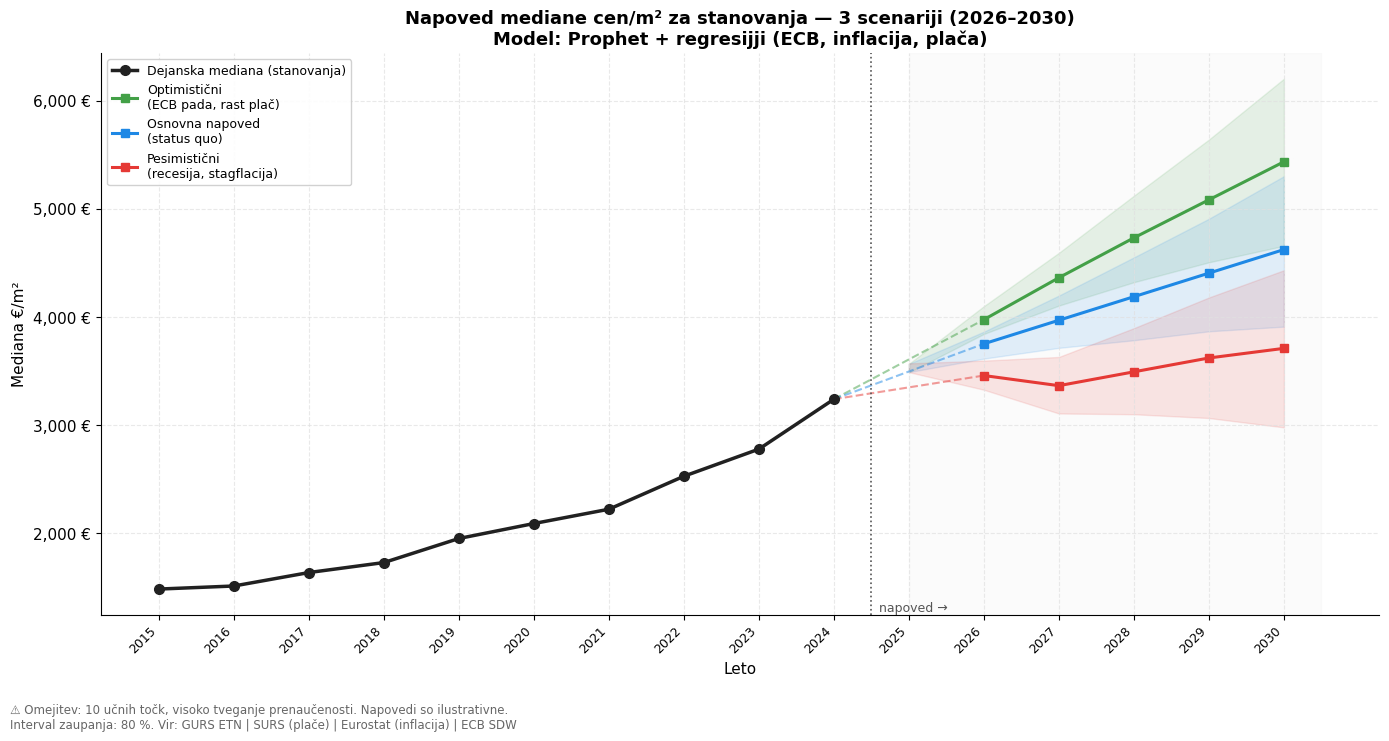

✓ Shranjeno: graf5_napoved_prophet.png


In [18]:
from prophet import Prophet
import logging
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

# ── Zgodovinski regresiji (2015–2024) ───────────────────────────────────────
# Inflacija SLO [%] — Vir: Eurostat / SURS (HICP)
INFLACIJA = {
    2015: 0.0, 2016: -0.2, 2017: 1.6, 2018: 1.9, 2019: 1.6,
    2020: -0.1, 2021: 4.9, 2022: 10.8, 2023: 7.0, 2024: 2.3,
}
# Plače in ECB že definirane v Grafu 4 (PLACE, ECB_RATE)

# Nacionalna mediana cen/m² — stanovanja, 2015–2024
nat_serija = (
    df[(df["TIP"] == "Stanovanje") & (df["LETO"] <= 2024)]
    .groupby("LETO")["CENA_M2"]
    .median()
    .reset_index()
)
nat_serija["ds"] = pd.to_datetime(nat_serija["LETO"].astype(str) + "-07-01")
nat_serija["y"]  = nat_serija["CENA_M2"]
nat_serija["ecb"]      = nat_serija["LETO"].map(ECB_RATE)
nat_serija["inflacija"] = nat_serija["LETO"].map(INFLACIJA)
nat_serija["placa"]    = nat_serija["LETO"].map(PLACE)

# ── Predpostavke za 3 scenarije (2025–2030) ─────────────────────────────────
# Optimistični: ECB pada, rast plač, nizka inflacija
# Baseline:     ECB stabilno, zmerna rast plač
# Pesimistični: ECB ostaja visok, recesija, stagflacija
SCENARIJI = {
    "Optimistični\n(ECB pada, rast plač)": {
        "ecb":       [2.65, 1.75, 1.25, 1.00, 1.00, 1.00],
        "inflacija": [2.0,  2.0,  1.8,  1.8,  1.8,  1.8],
        "placa":     [1750, 1870, 1980, 2090, 2200, 2310],
        "barva": "#43A047", "linestyle": "-",
    },
    "Osnovna napoved\n(status quo)": {
        "ecb":       [2.65, 2.50, 2.50, 2.50, 2.50, 2.50],
        "inflacija": [2.0,  2.5,  2.5,  2.5,  2.5,  2.5],
        "placa":     [1750, 1820, 1890, 1960, 2030, 2100],
        "barva": "#1E88E5", "linestyle": "-",
    },
    "Pesimistični\n(recesija, stagflacija)": {
        "ecb":       [2.65, 3.50, 4.00, 3.50, 3.00, 3.00],
        "inflacija": [2.0,  5.0,  6.0,  5.0,  4.0,  3.5],
        "placa":     [1750, 1760, 1750, 1780, 1810, 1840],
        "barva": "#E53935", "linestyle": "-",
    },
}
LETA_NAPOVED = [2025, 2026, 2027, 2028, 2029, 2030]

# ── Treniranje modela ────────────────────────────────────────────────────────
m = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.80,          # 80 % interval zaupanja
    changepoint_prior_scale=0.15, # manjša vrednost = gladkejši trend
)
m.add_regressor("ecb")
m.add_regressor("inflacija")
m.add_regressor("placa")
m.fit(nat_serija[["ds", "y", "ecb", "inflacija", "placa"]])

# ── Graf ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

# Zgodovinska serija
ax.plot(nat_serija["LETO"], nat_serija["y"],
        color="#212121", linewidth=2.5, marker="o", markersize=7,
        label="Dejanska mediana (stanovanja)", zorder=5)

for naziv, scen in SCENARIJI.items():
    future = pd.DataFrame({
        "ds":        pd.to_datetime([f"{l}-07-01" for l in LETA_NAPOVED]),
        "ecb":       scen["ecb"],
        "inflacija": scen["inflacija"],
        "placa":     scen["placa"],
    })
    forecast = m.predict(future)
    forecast["leto"] = LETA_NAPOVED

    # Samo napoved (2026–2030), 2025 je delno znan
    fc = forecast[forecast["leto"] >= 2026]
    fc_all = forecast  # za interval zaupanja

    ax.fill_between(fc_all["leto"], fc_all["yhat_lower"], fc_all["yhat_upper"],
                    alpha=0.12, color=scen["barva"])
    ax.plot(fc["leto"], fc["yhat"],
            color=scen["barva"], linewidth=2.2,
            linestyle=scen["linestyle"], marker="s", markersize=6,
            label=naziv)
    # Poveži zadnjo zgodovinsko točko z začetkom napovedi
    fc_2026 = forecast[forecast["leto"] == 2026].iloc[0]
    ax.plot([2024, 2026], [nat_serija["y"].iloc[-1], fc_2026["yhat"]],
            color=scen["barva"], linewidth=1.5, linestyle="--", alpha=0.5)

# Ločnica zgodovinsko / napoved
ax.axvline(x=2024.5, color="#555", linewidth=1.2, linestyle=":")
ax.text(2024.6, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 1000,
        "napoved →", fontsize=9, color="#555", va="bottom")
ax.axvspan(2025, 2030.5, color="#f5f5f5", alpha=0.4, zorder=0)

ax.set_title("Napoved mediane cen/m² za stanovanja — 3 scenariji (2026–2030)\nModel: Prophet + regresijji (ECB, inflacija, plača)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Leto")
ax.set_ylabel("Mediana €/m²")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f} €"))
ax.set_xticks(list(range(2015, 2031)))
ax.set_xticklabels(list(range(2015, 2031)), rotation=45, ha="right", fontsize=9)
ax.legend(fontsize=9, loc="upper left", framealpha=0.9, edgecolor="#ccc")

fig.text(0.01, -0.05,
         "⚠ Omejitev: 10 učnih točk, visoko tveganje prenaučenosti. Napovedi so ilustrativne.\n"
         "Interval zaupanja: 80 %. Vir: GURS ETN | SURS (plače) | Eurostat (inflacija) | ECB SDW",
         fontsize=8.5, color="#666")

plt.tight_layout()
plt.savefig("graf5_napoved_prophet.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Shranjeno: graf5_napoved_prophet.png")

---
## Graf 6 — Pregled po občinah: mediana €/m² in obseg trga (2015–2025)

10 subplotov, razporejenih geografsko (SZ → JV). Vsak prikazuje:
- **Črta + senčenje:** mediana €/m² po letih
- **Mehurčki:** število tržnih poslov (večji = več poslov)

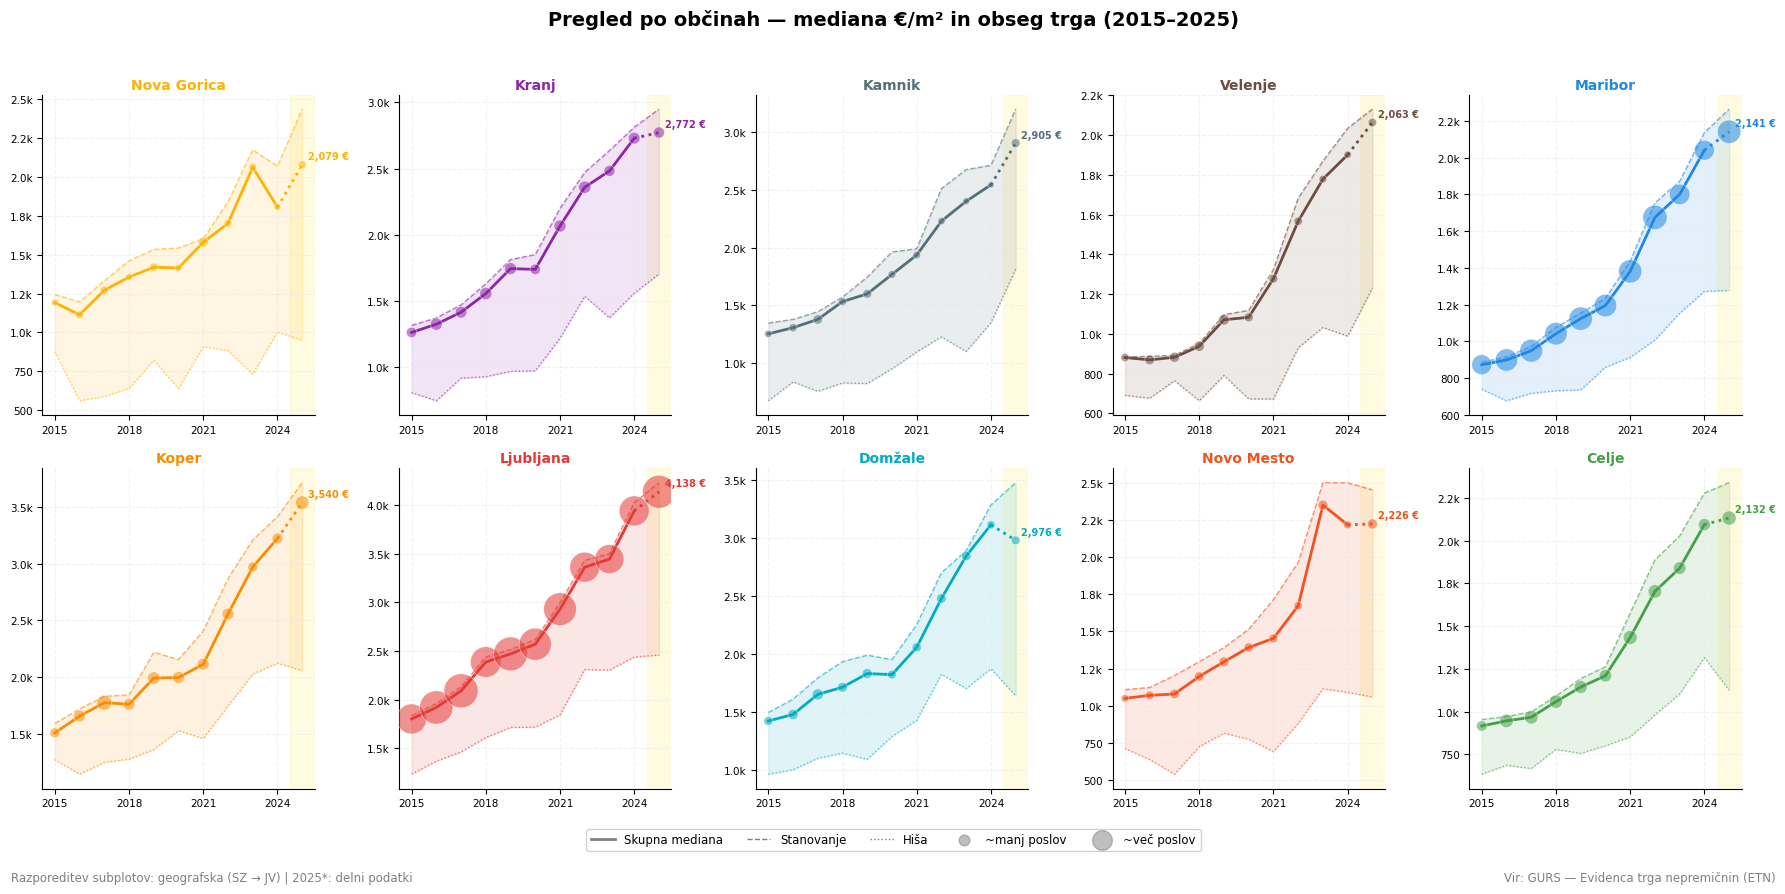

✓ Shranjeno: graf6_obcine_pregled.png


In [19]:
# Geografska mreža 2×5 (SZ → JV glede na koordinate)
GRID = [
    ["NOVA GORICA", "KRANJ",     "KAMNIK",    "VELENJE",   "MARIBOR"],
    ["KOPER",       "LJUBLJANA", "DOMŽALE",   "NOVO MESTO","CELJE"  ],
]
LETA = list(range(2015, 2026))

# Agregacija: mediana €/m² in število poslov po občini, tipu in letu
agg = (
    df.groupby(["OBCINA", "TIP", "LETO"])
    .agg(mediana=("CENA_M2", "median"), n=("CENA_M2", "count"))
    .reset_index()
)
agg_skupaj = (
    df.groupby(["OBCINA", "LETO"])
    .agg(mediana=("CENA_M2", "median"), n=("CENA_M2", "count"))
    .reset_index()
)

# Globalni razpon za skupno os y (vse občine, oba tipa)
y_min = agg["mediana"].min() * 0.9
y_max = agg["mediana"].max() * 1.08

# Normalizacija velikosti mehurčkov
n_max = agg_skupaj["n"].max()
BUBBLE_SCALE = 600  # max površina mehurčka v točkah²

fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharey=False)
fig.suptitle("Pregled po občinah — mediana €/m² in obseg trga (2015–2025)",
             fontsize=14, fontweight="bold", y=1.02)

for row_i, row in enumerate(GRID):
    for col_i, obcina in enumerate(row):
        ax = axes[row_i][col_i]
        barva = BARVE[obcina]

        pod_skupaj = agg_skupaj[agg_skupaj["OBCINA"] == obcina].sort_values("LETO")
        pod_stan   = agg[(agg["OBCINA"] == obcina) & (agg["TIP"] == "Stanovanje")].sort_values("LETO")
        pod_hisa   = agg[(agg["OBCINA"] == obcina) & (agg["TIP"] == "Hiša")].sort_values("LETO")

        # ── Senčenje med stanovanjem in hišo ────────────────────────────────
        if not pod_stan.empty and not pod_hisa.empty:
            leta_s = pod_stan["LETO"].tolist()
            leta_h = pod_hisa["LETO"].tolist()
            skupna_leta = sorted(set(leta_s) & set(leta_h))
            if skupna_leta:
                ys = pod_stan.set_index("LETO")["mediana"].reindex(skupna_leta)
                yh = pod_hisa.set_index("LETO")["mediana"].reindex(skupna_leta)
                ax.fill_between(skupna_leta, ys, yh, alpha=0.12, color=barva)

        # ── Črta: skupna mediana ─────────────────────────────────────────────
        if not pod_skupaj.empty:
            s24 = pod_skupaj[pod_skupaj["LETO"] <= 2024]
            s25 = pod_skupaj[pod_skupaj["LETO"] >= 2024]
            ax.plot(s24["LETO"], s24["mediana"], color=barva, linewidth=2, zorder=3)
            if len(s25) >= 2:
                ax.plot(s25["LETO"], s25["mediana"], color=barva,
                        linewidth=2, linestyle=":", zorder=3)

        # ── Mehurčki: število poslov ─────────────────────────────────────────
        if not pod_skupaj.empty:
            velikosti = (pod_skupaj["n"] / n_max * BUBBLE_SCALE).clip(lower=20)
            ax.scatter(pod_skupaj["LETO"], pod_skupaj["mediana"],
                       s=velikosti, color=barva, alpha=0.55, zorder=4,
                       edgecolors="white", linewidths=0.5)

        # ── Črti za stanovanje in hišo (tanjši) ─────────────────────────────
        for pod_tip, ls, alpha in [(pod_stan, "--", 0.6), (pod_hisa, ":", 0.6)]:
            if not pod_tip.empty:
                ax.plot(pod_tip["LETO"], pod_tip["mediana"],
                        color=barva, linewidth=1, linestyle=ls, alpha=alpha, zorder=2)

        # ── Ozadje 2025 ─────────────────────────────────────────────────────
        ax.axvspan(2024.5, 2025.5, color="#FFF9C4", alpha=0.5, zorder=0)

        # ── Osi in oznake ────────────────────────────────────────────────────
        ax.set_title(obcina.title(), fontsize=10, fontweight="bold",
                     color=barva, pad=4)
        ax.set_xlim(2014.5, 2025.5)
        ax.set_xticks([2015, 2018, 2021, 2024])
        ax.tick_params(axis="x", labelsize=7.5)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda v, _: f"{v/1000:.1f}k" if v >= 1000 else f"{v:.0f}"
        ))
        ax.tick_params(axis="y", labelsize=7.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(True, color="#e8e8e8", linestyle="--", alpha=0.6)

        # Zadnja vrednost kot anotacija
        if not pod_skupaj.empty:
            zadnja = pod_skupaj[pod_skupaj["LETO"] == pod_skupaj["LETO"].max()].iloc[0]
            ax.annotate(f"{zadnja['mediana']:,.0f} €",
                        xy=(zadnja["LETO"], zadnja["mediana"]),
                        xytext=(4, 4), textcoords="offset points",
                        fontsize=7, color=barva, fontweight="bold")

# ── Skupna legenda ───────────────────────────────────────────────────────────
from matplotlib.lines import Line2D
legenda_elementi = [
    Line2D([0], [0], color="gray", linewidth=2,        label="Skupna mediana"),
    Line2D([0], [0], color="gray", linewidth=1, linestyle="--", label="Stanovanje"),
    Line2D([0], [0], color="gray", linewidth=1, linestyle=":",  label="Hiša"),
    plt.scatter([], [], s=60,  color="gray", alpha=0.5, label="~manj poslov"),
    plt.scatter([], [], s=200, color="gray", alpha=0.5, label="~več poslov"),
]
fig.legend(handles=legenda_elementi, loc="lower center", ncol=5,
           fontsize=8.5, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))

fig.text(0.01, -0.07, "Razporeditev subplotov: geografska (SZ → JV) | 2025*: delni podatki",
         fontsize=8.5, color="gray")
fig.text(0.99, -0.07, "Vir: GURS — Evidenca trga nepremičnin (ETN)",
         fontsize=8.5, color="gray", ha="right")

plt.tight_layout()
plt.savefig("graf6_obcine_pregled.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Shranjeno: graf6_obcine_pregled.png")

---
## Graf 7 — Časovnica nacionalnih cen/m² s ključnimi dogodki (2015–2025)

---
## Graf A — Cenovni trend: mediana €/m² po občinah + heatmap (2015–2025)

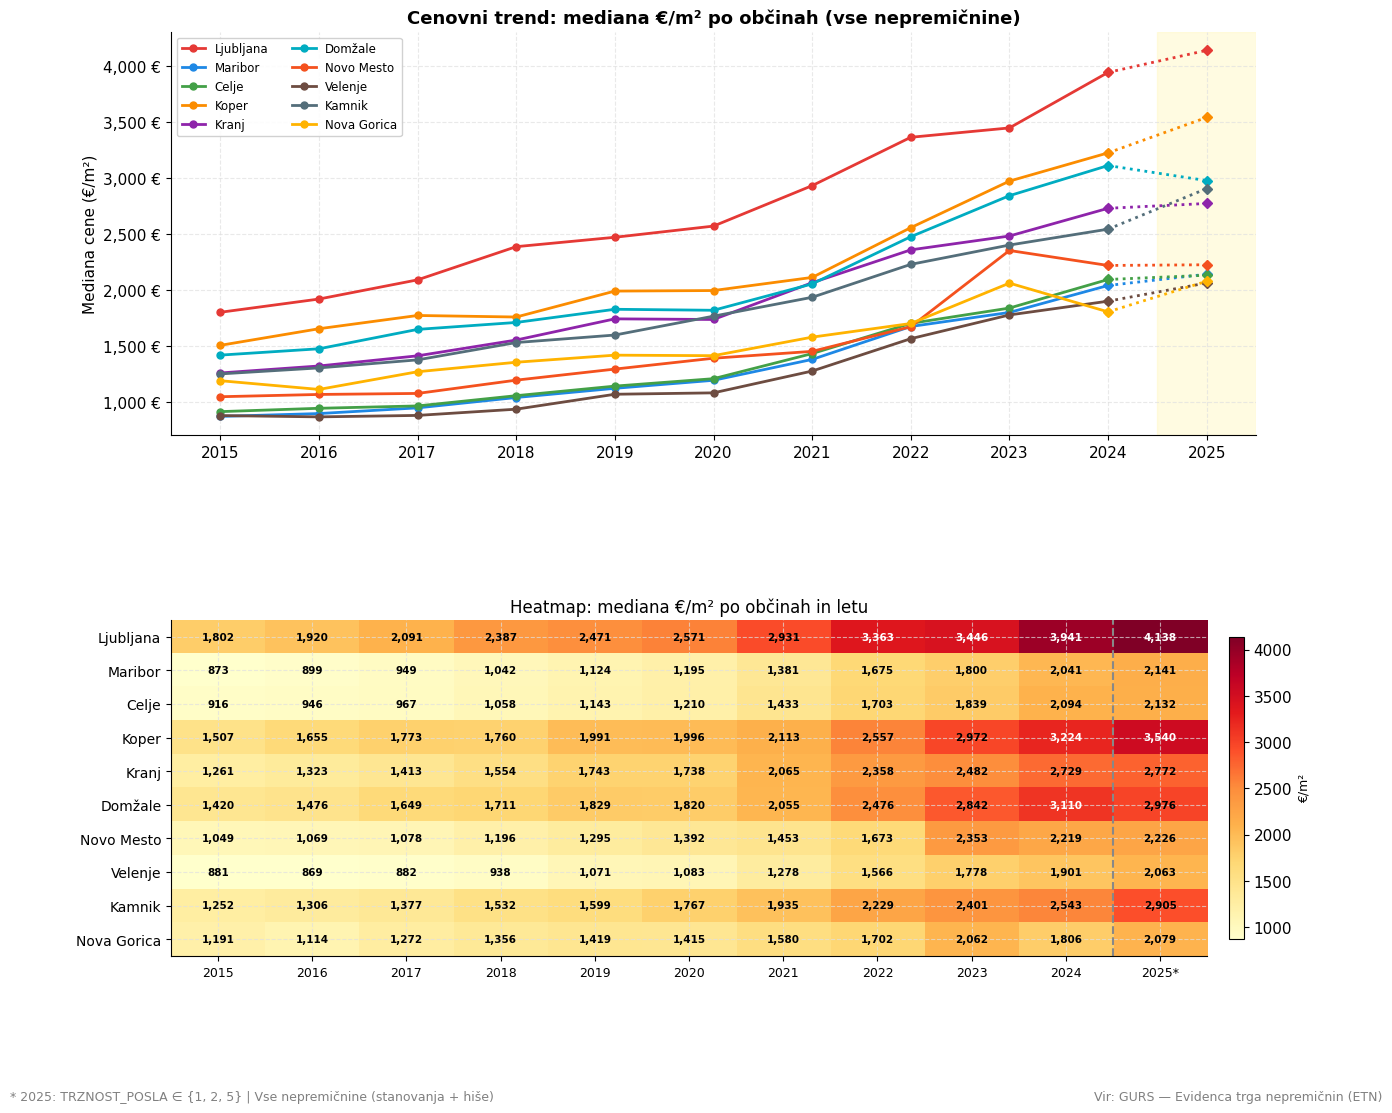

✓ Shranjeno: graf_cenovni_trend.png


In [20]:
import matplotlib.colors as mcolors

LETA_A = list(range(2015, 2026))

fig, (ax_line, ax_heat) = plt.subplots(2, 1, figsize=(14, 12),
                                        gridspec_kw={"height_ratios": [1.2, 1], "hspace": 0.5})

# ── Zgornji panel: linijski graf mediane €/m² (vse nepremičnine) ─────────────
pivot_vse = (
    df.groupby(["OBCINA", "LETO"])["CENA_M2"]
    .median()
    .reset_index()
)
for obcina in OBCINE:
    pod = pivot_vse[pivot_vse["OBCINA"] == obcina].sort_values("LETO")
    s24 = pod[pod["LETO"] <= 2024]
    s25 = pod[pod["LETO"] >= 2024]
    ax_line.plot(s24["LETO"], s24["CENA_M2"], color=BARVE[obcina],
                 linewidth=2, marker="o", markersize=5, label=obcina.title())
    if len(s25) >= 2:
        ax_line.plot(s25["LETO"], s25["CENA_M2"], color=BARVE[obcina],
                     linewidth=2, linestyle=":", marker="D", markersize=5)

ax_line.axvspan(2024.5, 2025.5, color="#FFF9C4", alpha=0.5, zorder=0)
ax_line.set_title("Cenovni trend: mediana €/m² po občinah (vse nepremičnine)", fontsize=13, fontweight="bold")
ax_line.set_ylabel("Mediana cene (€/m²)")
ax_line.set_xticks(LETA_A)
ax_line.set_xlim(2014.5, 2025.5)
ax_line.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f} €"))
ax_line.legend(fontsize=8.5, ncol=2, loc="upper left", framealpha=0.9, edgecolor="#ccc")

# ── Spodnji panel: heatmap z absolutnimi vrednostmi ──────────────────────────
heat_data = (
    pivot_vse.pivot(index="OBCINA", columns="LETO", values="CENA_M2")
    .reindex(OBCINE)
)
# Barvna lestvica od min do max
vmin_h = heat_data.values[~np.isnan(heat_data.values)].min()
vmax_h = heat_data.values[~np.isnan(heat_data.values)].max()
im = ax_heat.imshow(heat_data.values, aspect="auto",
                    cmap="YlOrRd", vmin=vmin_h, vmax=vmax_h,
                    interpolation="nearest")

for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        val = heat_data.values[i, j]
        if np.isnan(val): continue
        textcolor = "white" if val > vmax_h * 0.72 else "black"
        ax_heat.text(j, i, f"{val:,.0f}", ha="center", va="center",
                     fontsize=7.5, color=textcolor, fontweight="bold")

ax_heat.set_xticks(range(len(LETA_A)))
ax_heat.set_xticklabels([str(l) if l < 2025 else "2025*" for l in LETA_A], fontsize=9)
ax_heat.set_yticks(range(len(OBCINE)))
ax_heat.set_yticklabels([o.title() for o in OBCINE], fontsize=10)
ax_heat.set_title("Heatmap: mediana €/m² po občinah in letu", fontsize=12, pad=6)
ax_heat.axvline(x=len(LETA_A) - 1.5, color="#888", linewidth=1.5, linestyle="--")

cbar = fig.colorbar(im, ax=ax_heat, orientation="vertical", fraction=0.025, pad=0.02, shrink=0.9)
cbar.set_label("€/m²", fontsize=9)

fig.text(0.01, -0.01, "* 2025: TRZNOST_POSLA ∈ {1, 2, 5} | Vse nepremičnine (stanovanja + hiše)",
         fontsize=9, color="gray")
fig.text(0.99, -0.01, "Vir: GURS — Evidenca trga nepremičnin (ETN)",
         fontsize=9, color="gray", ha="right")

plt.savefig("graf_cenovni_trend.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Shranjeno: graf_cenovni_trend.png")

---
## Graf B — Hiše vs. stanovanja: cene, skupna vrednost, strukturni delež

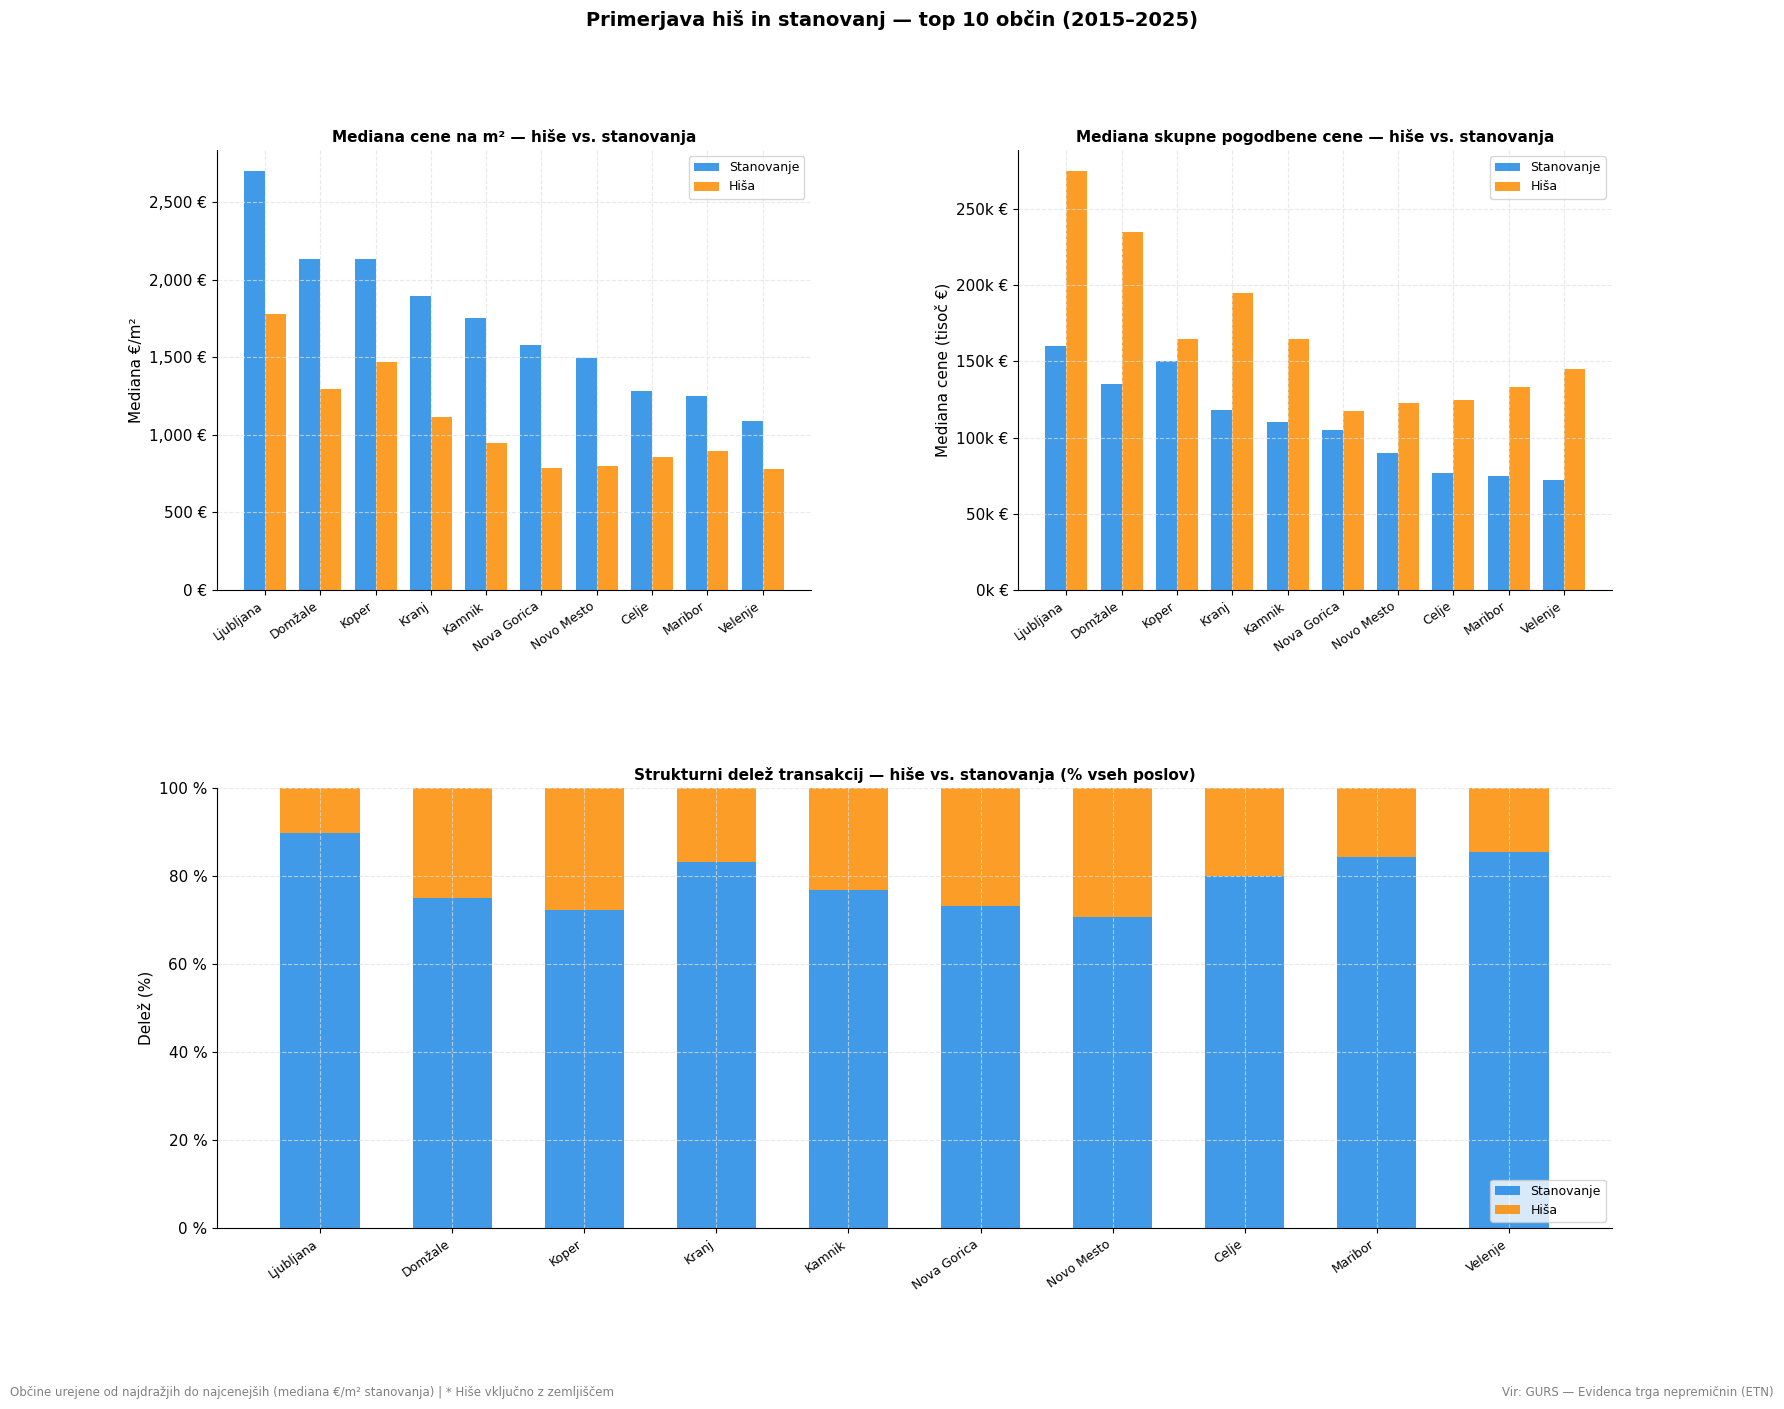

✓ Shranjeno: graf_hise_vs_stanovanja.png


In [21]:
# Agregirani podatki po občini in tipu (celotno obdobje)
agg_tip = (
    df[df["TIP"].isin(["Stanovanje", "Hiša"])]
    .groupby(["OBCINA", "TIP"])
    .agg(
        mediana_m2=("CENA_M2", "median"),
        mediana_skupaj=("POGODBENA_CENA_ODSKODNINA", "median"),
        n=("CENA_M2", "count"),
    )
    .reset_index()
)

# Ureditev občin po mediani cen/m² (stanovanje, od najdražjega)
red_obcine = (
    agg_tip[agg_tip["TIP"] == "Stanovanje"]
    .sort_values("mediana_m2", ascending=False)["OBCINA"]
    .tolist()
)

x = np.arange(len(red_obcine))
w = 0.38

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35)

# ── Panel 1: Mediana €/m² ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for i, tip in enumerate(["Stanovanje", "Hiša"]):
    vals = [agg_tip[(agg_tip["OBCINA"] == o) & (agg_tip["TIP"] == tip)]["mediana_m2"].values
            for o in red_obcine]
    vals = [v[0] if len(v) else 0 for v in vals]
    offset = -w/2 if i == 0 else w/2
    bars = ax1.bar(x + offset, vals, w, label=tip,
                   color=["#1E88E5", "#FB8C00"][i], alpha=0.85)

ax1.set_title("Mediana cene na m² — hiše vs. stanovanja", fontsize=11, fontweight="bold")
ax1.set_ylabel("Mediana €/m²")
ax1.set_xticks(x); ax1.set_xticklabels([o.title() for o in red_obcine], rotation=35, ha="right", fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f} €"))
ax1.legend(fontsize=9); ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)

# ── Panel 2: Mediana skupne cene ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for i, tip in enumerate(["Stanovanje", "Hiša"]):
    vals = [agg_tip[(agg_tip["OBCINA"] == o) & (agg_tip["TIP"] == tip)]["mediana_skupaj"].values
            for o in red_obcine]
    vals = [v[0]/1000 if len(v) else 0 for v in vals]
    offset = -w/2 if i == 0 else w/2
    ax2.bar(x + offset, vals, w, label=tip,
            color=["#1E88E5", "#FB8C00"][i], alpha=0.85)

ax2.set_title("Mediana skupne pogodbene cene — hiše vs. stanovanja", fontsize=11, fontweight="bold")
ax2.set_ylabel("Mediana cene (tisoč €)")
ax2.set_xticks(x); ax2.set_xticklabels([o.title() for o in red_obcine], rotation=35, ha="right", fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}k €"))
ax2.legend(fontsize=9); ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

# ── Panel 3: Strukturni delež (celotni spodnji pas) ──────────────────────────
ax3 = fig.add_subplot(gs[1, :])
tot = agg_tip.groupby("OBCINA")["n"].sum().reindex(red_obcine)
for tip, barva in [("Stanovanje", "#1E88E5"), ("Hiša", "#FB8C00")]:
    vals = [agg_tip[(agg_tip["OBCINA"] == o) & (agg_tip["TIP"] == tip)]["n"].values for o in red_obcine]
    vals = [v[0] / tot[o] * 100 if len(v) and tot[o] > 0 else 0 for v, o in zip(vals, red_obcine)]
    bottom = [100 - v for v in vals] if tip == "Hiša" else [0]*len(red_obcine)
    ax3.bar(x, vals, 0.6, bottom=bottom, label=tip, color=barva, alpha=0.85)

ax3.set_title("Strukturni delež transakcij — hiše vs. stanovanja (% vseh poslov)", fontsize=11, fontweight="bold")
ax3.set_ylabel("Delež (%)")
ax3.set_ylim(0, 100)
ax3.set_xticks(x); ax3.set_xticklabels([o.title() for o in red_obcine], rotation=35, ha="right", fontsize=9)
ax3.legend(fontsize=9, loc="lower right"); ax3.spines["top"].set_visible(False); ax3.spines["right"].set_visible(False)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f} %"))

fig.suptitle("Primerjava hiš in stanovanj — top 10 občin (2015–2025)", fontsize=14, fontweight="bold")
fig.text(0.01, -0.01, "Občine urejene od najdražjih do najcenejših (mediana €/m² stanovanja) | * Hiše vključno z zemljiščem",
         fontsize=8.5, color="gray")
fig.text(0.99, -0.01, "Vir: GURS — Evidenca trga nepremičnin (ETN)", fontsize=8.5, color="gray", ha="right")

plt.savefig("graf_hise_vs_stanovanja.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Shranjeno: graf_hise_vs_stanovanja.png")

---
## Graf C — Obseg trga: skupno število transakcij in letna dinamika

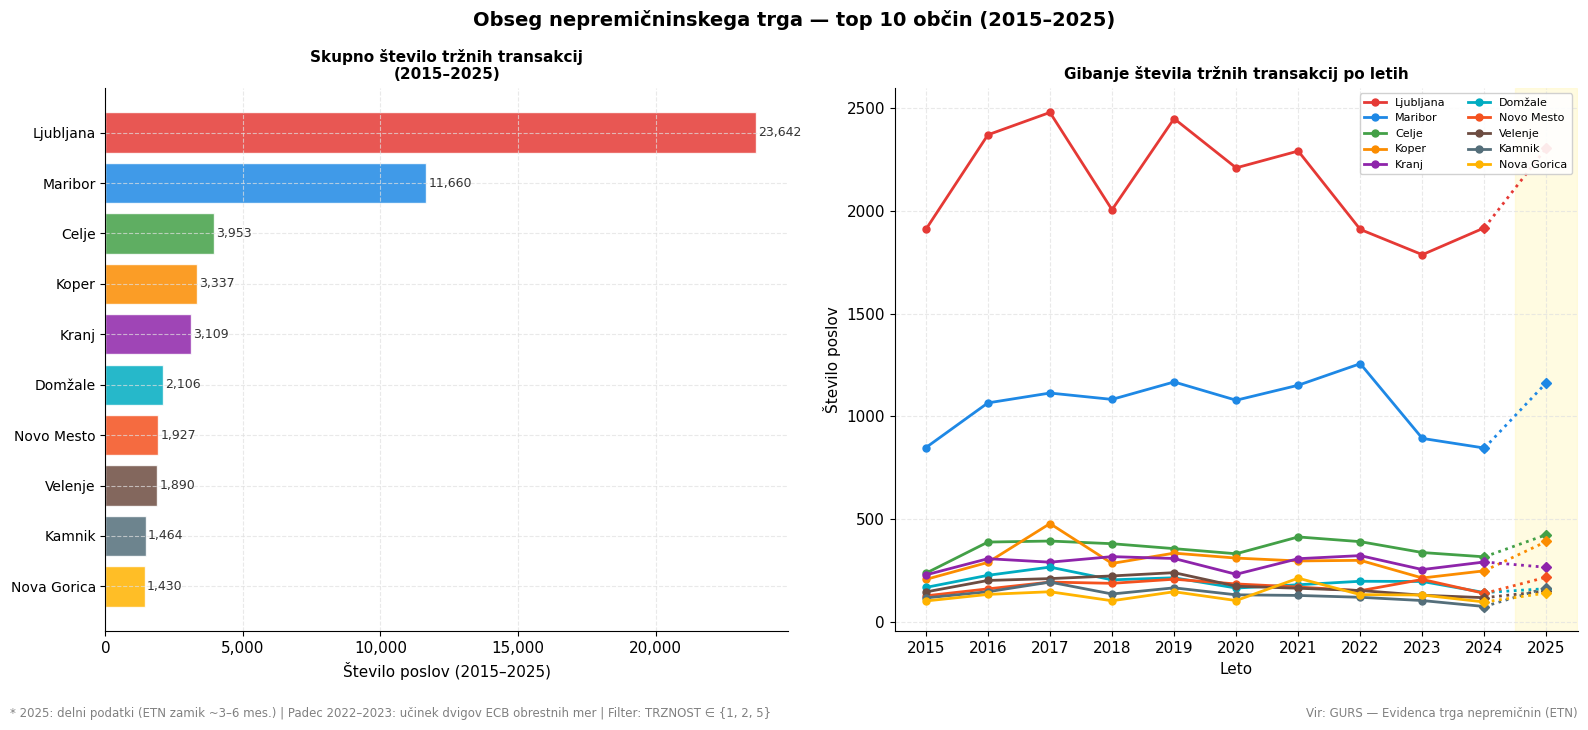

✓ Shranjeno: graf_obseg_trga.png


In [22]:
fig, (ax_bar, ax_line) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Obseg nepremičninskega trga — top 10 občin (2015–2025)", fontsize=14, fontweight="bold")

# ── Levo: horizontalni bar chart (skupno 2015–2025) ──────────────────────────
skupno = df.groupby("OBCINA").size().reindex(OBCINE).sort_values()
barve_sort = [BARVE[o] for o in skupno.index]

bars = ax_bar.barh(range(len(skupno)), skupno.values, color=barve_sort, alpha=0.85, edgecolor="white")
ax_bar.set_yticks(range(len(skupno)))
ax_bar.set_yticklabels([o.title() for o in skupno.index], fontsize=10)
ax_bar.set_xlabel("Število poslov (2015–2025)")
ax_bar.set_title("Skupno število tržnih transakcij\n(2015–2025)", fontsize=11, fontweight="bold")
ax_bar.spines["top"].set_visible(False); ax_bar.spines["right"].set_visible(False)
ax_bar.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

for bar, val in zip(bars, skupno.values):
    ax_bar.text(val + 80, bar.get_y() + bar.get_height()/2,
                f"{val:,}", va="center", fontsize=9, color="#333")

# ── Desno: linijski graf po letu ─────────────────────────────────────────────
letno = df.groupby(["OBCINA", "LETO"]).size().reset_index(name="N")
LETA_C = list(range(2015, 2026))

for obcina in OBCINE:
    pod = letno[letno["OBCINA"] == obcina].sort_values("LETO")
    s24 = pod[pod["LETO"] <= 2024]
    s25 = pod[pod["LETO"] >= 2024]
    ax_line.plot(s24["LETO"], s24["N"], color=BARVE[obcina],
                 linewidth=2, marker="o", markersize=5, label=obcina.title())
    if len(s25) >= 2:
        ax_line.plot(s25["LETO"], s25["N"], color=BARVE[obcina],
                     linewidth=2, linestyle=":", marker="D", markersize=5)

ax_line.axvspan(2024.5, 2025.5, color="#FFF9C4", alpha=0.5, zorder=0)
ax_line.set_title("Gibanje števila tržnih transakcij po letih", fontsize=11, fontweight="bold")
ax_line.set_ylabel("Število poslov")
ax_line.set_xlabel("Leto")
ax_line.set_xticks(LETA_C)
ax_line.set_xlim(2014.5, 2025.5)
ax_line.legend(fontsize=8, ncol=2, loc="upper right", framealpha=0.9, edgecolor="#ccc")
ax_line.spines["top"].set_visible(False); ax_line.spines["right"].set_visible(False)

fig.text(0.01, -0.03, "* 2025: delni podatki (ETN zamik ~3–6 mes.) | Padec 2022–2023: učinek dvigov ECB obrestnih mer | Filter: TRZNOST ∈ {1, 2, 5}",
         fontsize=8.5, color="gray")
fig.text(0.99, -0.03, "Vir: GURS — Evidenca trga nepremičnin (ETN)", fontsize=8.5, color="gray", ha="right")

plt.tight_layout()
plt.savefig("graf_obseg_trga.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Shranjeno: graf_obseg_trga.png")

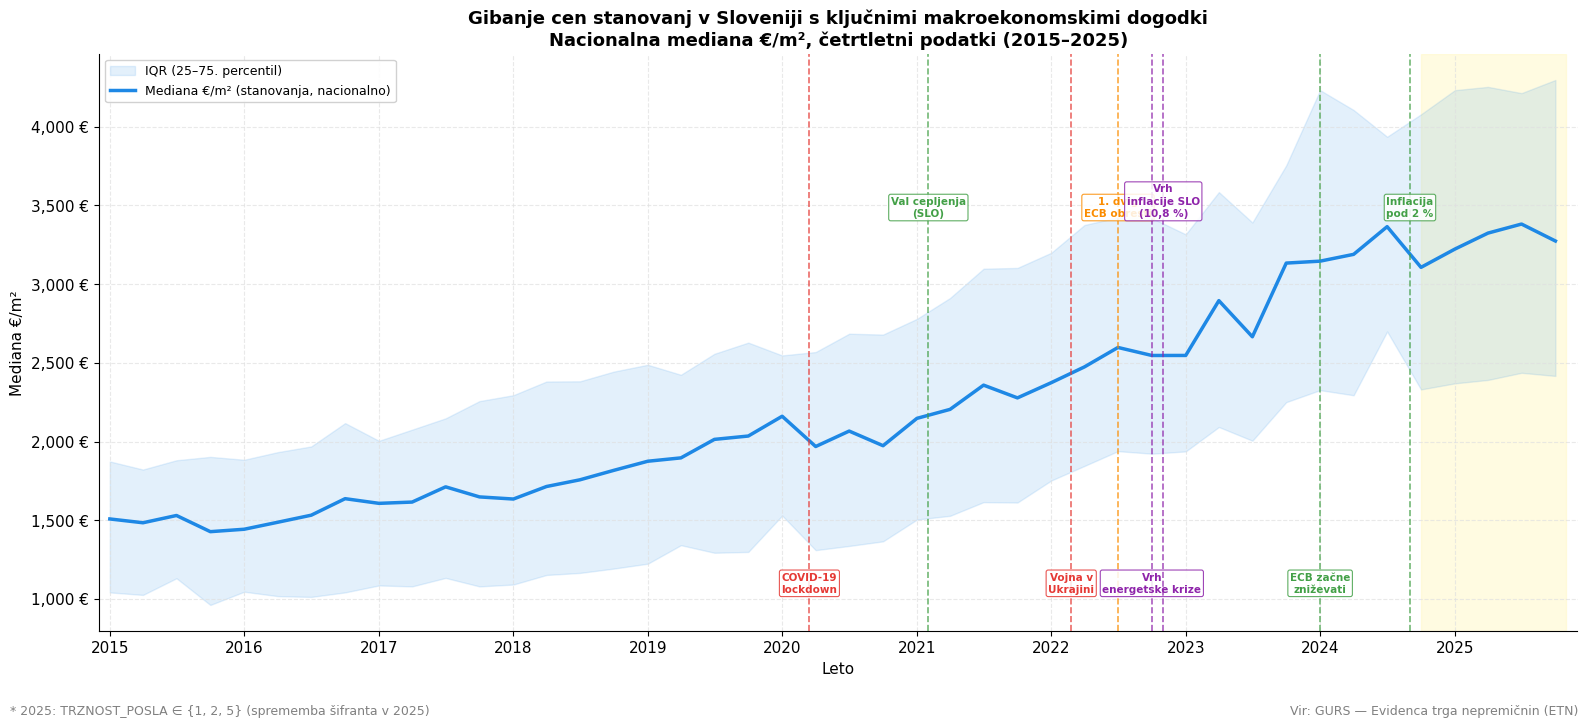

✓ Shranjeno: graf7_casovnica.png


In [23]:
import matplotlib.patheffects as pe

# ── Nacionalna mediana €/m² po četrtletjih ───────────────────────────────────
df["DATUM"] = pd.to_datetime(df["DATUM_UVELJAVITVE"], dayfirst=True, errors="coerce")
df["KVARTAL"] = df["DATUM"].dt.to_period("Q")

nat_q = (
    df[df["TIP"] == "Stanovanje"]
    .groupby("KVARTAL")["CENA_M2"]
    .median()
    .reset_index()
)
nat_q["DATUM_NUM"] = nat_q["KVARTAL"].apply(lambda q: q.start_time)
nat_q = nat_q.sort_values("DATUM_NUM")

# ── Ključni dogodki ──────────────────────────────────────────────────────────
# (datum, kratek napis, stran: "zgoraj"/"spodaj", barva)
DOGODKI = [
    ("2020-03-15", "COVID-19\nlockdown",          "spodaj", "#E53935"),
    ("2021-02-01", "Val cepljenja\n(SLO)",         "zgoraj", "#43A047"),
    ("2022-02-24", "Vojna v\nUkrajini",            "spodaj", "#E53935"),
    ("2022-07-01", "1. dvig\nECB obresti",         "zgoraj", "#FB8C00"),
    ("2022-10-01", "Vrh\nenergetske krize",        "spodaj", "#8E24AA"),
    ("2022-11-01", "Vrh\ninflacije SLO\n(10,8 %)", "zgoraj", "#8E24AA"),
    ("2024-01-01", "ECB začne\nzniževati",         "spodaj", "#43A047"),
    ("2024-09-01", "Inflacija\npod 2 %",           "zgoraj", "#43A047"),
]

# ── Graf ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))

# Senčenje — 80 % interval (rolling IQR)
nat_q_lo = (
    df[df["TIP"] == "Stanovanje"]
    .groupby("KVARTAL")["CENA_M2"]
    .quantile(0.25)
    .reset_index()
    .rename(columns={"CENA_M2": "q25"})
)
nat_q_hi = (
    df[df["TIP"] == "Stanovanje"]
    .groupby("KVARTAL")["CENA_M2"]
    .quantile(0.75)
    .reset_index()
    .rename(columns={"CENA_M2": "q75"})
)
band = nat_q.merge(nat_q_lo, on="KVARTAL").merge(nat_q_hi, on="KVARTAL")

ax.fill_between(band["DATUM_NUM"], band["q25"], band["q75"],
                color="#1E88E5", alpha=0.12, label="IQR (25–75. percentil)")

# Glavna črta
ax.plot(nat_q["DATUM_NUM"], nat_q["CENA_M2"],
        color="#1E88E5", linewidth=2.5, label="Mediana €/m² (stanovanja, nacionalno)")

# Oznaka 2025
ax.axvspan(pd.Timestamp("2024-10-01"), nat_q["DATUM_NUM"].max() + pd.Timedelta(days=30),
           color="#FFF9C4", alpha=0.5, zorder=0)

# ── Vertikalne črte z anotacijami ────────────────────────────────────────────
y_min_ax, y_max_ax = ax.get_ylim()
y_range = y_max_ax - y_min_ax

# Dinamično določi y pozicijo za oznako (zgoraj ali spodaj)
y_zg  = nat_q["CENA_M2"].max() * 1.01
y_sp  = nat_q["CENA_M2"].min() * 0.82

for datum_str, napis, stran, barva in DOGODKI:
    datum = pd.Timestamp(datum_str)

    ax.axvline(x=datum, color=barva, linewidth=1.2, linestyle="--", alpha=0.75, zorder=3)

    y_pos  = y_zg if stran == "zgoraj" else y_sp
    va     = "bottom" if stran == "zgoraj" else "top"

    t = ax.text(datum, y_pos, napis,
                ha="center", va=va, fontsize=7.5, color=barva,
                fontweight="bold", linespacing=1.3,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=barva,
                          alpha=0.85, linewidth=0.8))

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f} €"))
ax.set_xlabel("Leto")
ax.set_ylabel("Mediana €/m²")
ax.set_title("Gibanje cen stanovanj v Sloveniji s ključnimi makroekonomskimi dogodki\n"
             "Nacionalna mediana €/m², četrtletni podatki (2015–2025)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="upper left", framealpha=0.9)

import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlim(nat_q["DATUM_NUM"].min() - pd.Timedelta(days=30),
            nat_q["DATUM_NUM"].max() + pd.Timedelta(days=60))

fig.text(0.01, -0.03, "* 2025: TRZNOST_POSLA ∈ {1, 2, 5} (sprememba šifranta v 2025)",
         fontsize=9, color="gray")
fig.text(0.99, -0.03, "Vir: GURS — Evidenca trga nepremičnin (ETN)",
         fontsize=9, color="gray", ha="right")

plt.tight_layout()
plt.savefig("graf7_casovnica.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Shranjeno: graf7_casovnica.png")

---
## Graf 8 — Geografska porazdelitev prodaj po občinah
Vsaka prodana nepremičnina kot točka na karti, obarvana po ceni/m² (zelena = nizka, rdeča = visoka).  
Vir mej občin: GADM 4.1 (gadm.org) | Kartografska podlaga: OpenStreetMap © OpenStreetMap contributors

In [24]:
import ssl, urllib.request, json, os
import geopandas as gpd
import contextily as ctx
from pyproj import Transformer
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.stats import gaussian_kde

# ── GADM meje ────────────────────────────────────────────────────────────────
GADM_LOCAL = "gadm41_SVN_2.json"
if not os.path.exists(GADM_LOCAL):
    ssl_ctx = ssl.create_default_context()
    ssl_ctx.check_hostname = False
    ssl_ctx.verify_mode = ssl.CERT_NONE
    url = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_SVN_2.json"
    with urllib.request.urlopen(url, timeout=30, context=ssl_ctx) as r:
        with open(GADM_LOCAL, "wb") as f: f.write(r.read())
meje = gpd.read_file(GADM_LOCAL)

GADM_IMENA = {
    "LJUBLJANA": "Ljubljana", "MARIBOR": "Maribor", "CELJE": "Celje",
    "KOPER": "Koper", "KRANJ": "Kranj", "DOMŽALE": "Domžale",
    "NOVO MESTO": "NovoMesto", "VELENJE": "Velenje",
    "KAMNIK": "Kamnik", "NOVA GORICA": "NovaGorica",
}

# Per-municipality: (KDE bandwidth, KDE threshold, force_square, gridsize)
TUNE = {
    "LJUBLJANA":   (None,  0.10, False,  75),
    "MARIBOR":     (None,  0.10, False,  62),
    "CELJE":       (None,  0.10, False,  65),
    "KOPER":       (0.15,  0.28, False, 115),
    "KRANJ":       (0.15,  0.25, True,   85),  # ZMANJSAJ (70→85)
    "DOMŽALE":     (None,  0.10, True,   55),
    "NOVO MESTO":  (0.15,  0.22, False,  92),
    "VELENJE":     (None,  0.10, False,  68),
    "KAMNIK":      (0.15,  0.22, True,   78),
    "NOVA GORICA": (None,  0.10, False, 105),  # ZMANJSAJ (90→105)
}

# Zamik hexbinov — (dx_frac, dy_frac) kot delež vidnega razpona
# +x = desno, -y = dol; 1cm ≈ 0.04, 2cm ≈ 0.08, 3cm ≈ 0.12
SHIFT = {
    "KAMNIK":      (+0.16,  0.00),   # še +2cm desno (skupaj 4cm)
    "KOPER":       (+0.08, -0.12),   # +2cm desno, +1cm dol
    "KRANJ":       (+0.08,  0.00),   # enako
    "MARIBOR":     ( 0.00, -0.08),   # 2cm dol (novo)
    "NOVA GORICA": (+0.16,  0.00),   # še +2cm desno (skupaj 4cm)
    "NOVO MESTO":  ( 0.00, -0.16),   # še +1cm dol (skupaj 4cm)
    "VELENJE":     ( 0.00, -0.12),   # enako
}

# ── Koordinate → Web Mercator ─────────────────────────────────────────────────
transformer = Transformer.from_crs("EPSG:3912", "EPSG:3857", always_xy=True)
df_geo = df[df["E_CENTROID"].notna() & df["N_CENTROID"].notna() &
            (df["E_CENTROID"] > 0) & (df["N_CENTROID"] > 0)].copy()
xs, ys = transformer.transform(df_geo["E_CENTROID"].values, df_geo["N_CENTROID"].values)
df_geo["X_3857"] = xs
df_geo["Y_3857"] = ys

rng = np.random.default_rng(42)

for obcina in OBCINE:
    meja = meje[meje["NAME_2"] == GADM_IMENA[obcina]].to_crs("EPSG:3857")
    if meja.empty:
        print(f"⚠ {obcina}: meja ni najdena"); continue
    pod = df_geo[df_geo["OBCINA"] == obcina].copy()
    if len(pod) < 5: continue

    x_vals = pod["X_3857"].values
    y_vals = pod["Y_3857"].values
    kde_bw, kde_thr, force_square, gridsize = TUNE[obcina]

    # ── KDE: gosto jedro prodaj ──────────────────────────────────────────────
    n_s = min(3000, len(x_vals))
    idx_s = rng.choice(len(x_vals), n_s, replace=False)
    x_s, y_s = x_vals[idx_s], y_vals[idx_s]
    kde_obj = (gaussian_kde(np.vstack([x_s, y_s]), bw_method=kde_bw)
               if kde_bw else gaussian_kde(np.vstack([x_s, y_s])))
    gest = kde_obj(np.vstack([x_s, y_s]))
    jedro = gest >= gest.max() * kde_thr
    x_core, y_core = x_s[jedro], y_s[jedro]

    xlo, xhi = x_core.min(), x_core.max()
    ylo, yhi = y_core.min(), y_core.max()
    if xhi - xlo < 2000:
        cx = (xlo + xhi) / 2; xlo, xhi = cx - 1000, cx + 1000
    if yhi - ylo < 2000:
        cy = (ylo + yhi) / 2; ylo, yhi = cy - 1000, cy + 1000

    if force_square:
        w_pad = (xhi - xlo) * 1.18
        h_pad = (yhi - ylo) * 1.18
        side  = max(w_pad, h_pad)
        cx, cy = (xlo + xhi) / 2, (ylo + yhi) / 2
        xl = (cx - side / 2, cx + side / 2)
        yl = (cy - side / 2, cy + side / 2)
        fig_w = fig_h = 12.0
    else:
        pad_x = (xhi - xlo) * 0.18
        pad_y = (yhi - ylo) * 0.18
        xl = (xlo - pad_x, xhi + pad_x)
        yl = (ylo - pad_y, yhi + pad_y)
        w_m = xl[1] - xl[0]
        h_m = yl[1] - yl[0]
        AXES_W = 10.5
        AXES_H = np.clip(AXES_W * (h_m / w_m), 5.0, 15.0)
        fig_w = AXES_W + 1.4
        fig_h = AXES_H + 1.6

    # ── Zamik hexbinov (karta/meja ostaneta na mestu) ────────────────────────
    dx_f, dy_f = SHIFT.get(obcina, (0.0, 0.0))
    x_plot = x_vals + dx_f * (xl[1] - xl[0])
    y_plot = y_vals + dy_f * (yl[1] - yl[0])

    v_min = pod["CENA_M2"].quantile(0.05)
    v_max = pod["CENA_M2"].quantile(0.95)
    norm = Normalize(vmin=v_min, vmax=v_max)
    cmap = plt.cm.RdYlGn_r

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    ax.set_xlim(*xl); ax.set_ylim(*yl)
    try:
        ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik,
                        zoom="auto", attribution=False, reset_extent=False)
    except Exception:
        pass
    ax.set_xlim(*xl); ax.set_ylim(*yl)

    meja.plot(ax=ax, facecolor="none", edgecolor=BARVE[obcina], linewidth=2.5, zorder=3)

    ax.hexbin(x_plot, y_plot,
              C=pod["CENA_M2"].values,
              reduce_C_function=np.median,
              gridsize=gridsize,
              cmap=cmap, norm=norm,
              mincnt=1, alpha=0.82,
              linewidths=0.2, edgecolors="white",
              zorder=4)

    ax.set_xlim(*xl); ax.set_ylim(*yl)

    sm = ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, shrink=0.7)
    cbar.set_label("Mediana cene/m² (€)", fontsize=11)
    cbar.ax.tick_params(labelsize=9)
    cbar.set_ticks([v_min, (v_min + v_max) / 2, v_max])
    cbar.set_ticklabels([f"{v_min:,.0f} €", f"{(v_min+v_max)/2:,.0f} €", f"{v_max:,.0f} €"])

    ax.set_title(
        f"Porazdelitev prodaj — {obcina.title()} (2015–2025)\n"
        f"n = {len(pod):,} tržnih poslov | mediana: {pod['CENA_M2'].median():,.0f} €/m²",
        fontsize=13, fontweight="bold", pad=10)
    ax.set_axis_off()
    fig.text(0.01, 0.01,
             "Vir: GURS ETN | Meje: GADM 4.1 | Karte: © OpenStreetMap contributors",
             fontsize=8, color="gray")

    plt.tight_layout()
    ime = f"koordinate_{obcina.replace(' ', '_')}.png"
    plt.savefig(ime, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"✓ {ime}  [gs={gridsize}, shift={SHIFT.get(obcina,(0,0))}]")

✓ koordinate_LJUBLJANA.png  [gs=75, shift=(0, 0)]
✓ koordinate_MARIBOR.png  [gs=62, shift=(0.0, -0.08)]
✓ koordinate_CELJE.png  [gs=65, shift=(0, 0)]
✓ koordinate_KOPER.png  [gs=115, shift=(0.08, -0.12)]
✓ koordinate_KRANJ.png  [gs=85, shift=(0.08, 0.0)]
✓ koordinate_DOMŽALE.png  [gs=55, shift=(0, 0)]
✓ koordinate_NOVO_MESTO.png  [gs=92, shift=(0.0, -0.16)]
✓ koordinate_VELENJE.png  [gs=68, shift=(0.0, -0.12)]
✓ koordinate_KAMNIK.png  [gs=78, shift=(0.16, 0.0)]
✓ koordinate_NOVA_GORICA.png  [gs=105, shift=(0.16, 0.0)]
